# ResNet-50 Experiment Notebook

This notebook contains the full experimentation process for the ResNet-50 model, including baseline training, tuning attempts, intermediate comparisons, and final model selection.

Some outputs may reflect the original local runtime environment used during experimentation. This notebook is included as experiment history rather than the primary rerunnable notebook.

**GitHub note:** This notebook is included as experiment history. For a polished final summary, see `notebooks/final/ResNet50_FINAL.ipynb`. For a cleaner rerun/evaluation workflow, see `notebooks/reproducibility/ResNet50_Reproducibility.ipynb`.

**Final model note:** Earlier runs such as R08 are included for comparison. The final selected ResNet-50 configuration is R13 with `ReduceLROnPlateau`.


# ResNet-50 Experiments

This notebook trains ResNet-50 from scratch for image-level real vs fake face classification using the Kaggle 140k dataset.
Primary model-selection metric: Validation F1-score.
The test split is reserved for final evaluation only.

## Run First After Restart / Shutdown

Every time you restart the kernel or shut down your PC, run the setup cells **from Section 1 through Section 11.1** before running any experiment cell.

Run these in order:
1. **Imports**
2. **Device Setup**
3. **Project Paths and Dataset Paths**
4. **Data Transforms / Augmentations**
5. **Datasets, Dataloaders, and Dataloader Builder**
6. **Batch Sanity Check**
7. **Model Definition**
8. **Metric Functions**
9. **Training Function**
10. **Validation Function**
11. **Experiment Runner**
11.1 **Restart Setup Check**

After those cells are loaded, you can jump directly to the experiment you want to run, such as R12 batch size tuning.

Important: `run_experiment(config)` now rebuilds dataloaders inside the function using `config["batch_size"]` and `config["augmentation"]`. This prevents accidentally using an old global dataloader with batch size 8.


## 1. Imports

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet50

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


## 2. Device Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce GTX 1080 Ti


## 3. Project Paths and Dataset Paths
This section defines the project folders and the train, validation, and test dataset locations.
Save the dataset into your deskptop.

In [3]:
project_root = Path.cwd().parent
results_dir = project_root / "results"
checkpoints_dir = project_root / "checkpoints"

results_dir.mkdir(exist_ok=True)
checkpoints_dir.mkdir(exist_ok=True)

data_root = Path.home() / "Desktop" / "real-vs-fake" / "real_vs_fake" / "real-vs-fake"

train_dir = data_root / "train"
val_dir = data_root / "valid"
test_dir = data_root / "test"   # defined only; do not use until final evaluation

print("Home:", Path.home())
print("Data root:", data_root)
print("Train dir:", train_dir)
print("Val dir:", val_dir)
print("Test dir:", test_dir)

print("Train exists:", train_dir.exists())
print("Val exists:", val_dir.exists())
print("Test exists:", test_dir.exists())

Home: C:\Users\Richa
Data root: C:\Users\Richa\Desktop\real-vs-fake\real_vs_fake\real-vs-fake
Train dir: C:\Users\Richa\Desktop\real-vs-fake\real_vs_fake\real-vs-fake\train
Val dir: C:\Users\Richa\Desktop\real-vs-fake\real_vs_fake\real-vs-fake\valid
Test dir: C:\Users\Richa\Desktop\real-vs-fake\real_vs_fake\real-vs-fake\test
Train exists: True
Val exists: True
Test exists: True


## 4. Data Transforms

In [4]:
input_size = 224

light_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

medium_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

strong_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    transforms.RandomRotation(15),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# Alias used by earlier baseline cells.
train_transform = light_transform

print("Input size:", input_size)
print("Available training augmentations: light, medium, strong")
print("Default training augmentation: light")


Input size: 224
Available training augmentations: light, medium, strong
Default training augmentation: light


## 5. Datasets and Dataloaders

In [5]:
def get_dataloaders(augmentation_name="light", batch_size=8):
    if augmentation_name == "light":
        selected_train_transform = light_transform
    elif augmentation_name == "medium":
        selected_train_transform = medium_transform
    elif augmentation_name == "strong":
        selected_train_transform = strong_transform
    else:
        raise ValueError(f"Unsupported augmentation setting: {augmentation_name}")

    train_dataset = datasets.ImageFolder(train_dir, transform=selected_train_transform)
    val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    return train_loader, val_loader

# Default loaders for quick sanity checks only.
# Experiment runs create their own loaders from each config.
batch_size = 8
train_loader, val_loader = get_dataloaders("light", batch_size=batch_size)
train_dataset = train_loader.dataset
val_dataset = val_loader.dataset

print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Default sanity-check batch size:", batch_size)

Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}
Train size: 100000
Val size: 20000
Default sanity-check batch size: 8


## 6. Batch Sanity Check

In [6]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 8 labels:", labels[:8])
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image batch shape: torch.Size([8, 3, 224, 224])
Label batch shape: torch.Size([8])
First 8 labels: tensor([0, 0, 0, 1, 0, 0, 1, 1])
Image dtype: torch.float32
Label dtype: torch.int64


## 7. Model Definition

In [7]:
def get_resnet50(num_classes=2):
    model = resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [8]:
model = get_resnet50(num_classes=2)
print(model.fc)

Linear(in_features=2048, out_features=2, bias=True)


## 8. Metric Functions

In [9]:
def compute_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics["roc_auc"] = float("nan")

    return metrics

In [10]:
y_true = [0, 1, 0, 1]
y_pred = [0, 1, 0, 0]
y_prob = [0.1, 0.9, 0.2, 0.4]

print(compute_metrics(y_true, y_pred, y_prob))

{'accuracy': 0.75, 'precision': 1.0, 'recall': 0.5, 'f1': 0.6666666666666666, 'roc_auc': 1.0}



## 9. Training Function

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

## 10. Validation Function

In [12]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss
    return metrics

##### Plot Output Folder

`plots_dir` is created in the Project Paths cell. Run this cell only if you want to confirm where plots will be saved.

In [13]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


## 11. Experiment Runner

### Scheduler Update Note

The experiment runner was updated so that a scheduler can be optionally controlled through the `config` dictionary.

Supported scheduler setting:
- `"none"`
- `"ReduceLROnPlateau"`

If enabled, the scheduler updates based on validation loss.

In [14]:
def run_experiment(config):
    print(f"Starting run: {config['run_id']}")

    # Default old configs to batch size 8, but always let explicit configs override it.
    run_batch_size = int(config.get("batch_size", 8))
    run_augmentation = config.get("augmentation", "light")

    train_loader, val_loader = get_dataloaders(
        augmentation_name=run_augmentation,
        batch_size=run_batch_size
    )

    # Safety check: prevents accidentally training with stale/global loaders.
    assert train_loader.batch_size == run_batch_size, (
        f"Train loader batch size {train_loader.batch_size} does not match config batch size {run_batch_size}"
    )
    assert val_loader.batch_size == run_batch_size, (
        f"Val loader batch size {val_loader.batch_size} does not match config batch size {run_batch_size}"
    )

    print(f"Using augmentation: {run_augmentation}")
    print(f"Using batch size: {run_batch_size}")

    model = get_resnet50(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()

    if config["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
    elif config["optimizer"] == "AdamW":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
    elif config["optimizer"] == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=config["lr"],
            momentum=0.9,
            weight_decay=config["weight_decay"]
        )
    else:
        raise ValueError(f"Unsupported optimizer: {config['optimizer']}")
    
    scheduler = None
    if config.get("scheduler", "none") == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=1
        )

    best_val_f1 = -1.0
    best_epoch = -1
    patience_counter = 0
    history = []

    checkpoint_path = checkpoints_dir / f"{config['run_id']}_best.pth"
    start_time = time.time()

    for epoch in range(config["epochs"]):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        history_row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
        }
        history.append(history_row)

        print(
            f"Epoch {epoch+1}/{config['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )
        
        if scheduler is not None:
            scheduler.step(val_metrics["loss"])

        if np.isnan(train_loss) or np.isnan(val_metrics["loss"]):
            print("Stopping early: loss became NaN")
            break

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                "run_id": config["run_id"],
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_f1": best_val_f1,
                "config": {**config, "batch_size": run_batch_size, "augmentation": run_augmentation},
            }, checkpoint_path)
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print("Early stopping triggered.")
            break

    elapsed_minutes = (time.time() - start_time) / 60.0

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["val_f1"].idxmax()].to_dict()

    run_result = {
        "run_id": config["run_id"],
        "model": "ResNet-50",
        "run_type": config["run_type"],
        "batch_size": run_batch_size,
        "epochs": config["epochs"],
        "optimizer": config["optimizer"],
        "learning_rate": config["lr"],
        "weight_decay": config["weight_decay"],
        "augmentation": run_augmentation,
        "scheduler": config.get("scheduler", "none"),
        "val_loss": best_row["val_loss"],
        "val_accuracy": best_row["val_accuracy"],
        "val_precision": best_row["val_precision"],
        "val_recall": best_row["val_recall"],
        "val_f1": best_row["val_f1"],
        "val_roc_auc": best_row["val_roc_auc"],
        "best_epoch": int(best_row["epoch"]),
        "train_time_min": elapsed_minutes,
        "checkpoint_saved": str(checkpoint_path.name),
        "notes": config.get("notes", ""),
    }

    csv_path = results_dir / "experiment_log.csv"
    if csv_path.exists():
        df_existing = pd.read_csv(csv_path)
        # Replace an old row with the same run_id instead of accidentally keeping stale duplicates.
        df_existing = df_existing[df_existing["run_id"] != config["run_id"]]
        df_new = pd.concat([df_existing, pd.DataFrame([run_result])], ignore_index=True)
    else:
        df_new = pd.DataFrame([run_result])

    df_new.to_csv(csv_path, index=False)

    print(f"Saved results to {csv_path}")
    print(f"Saved best checkpoint to {checkpoint_path}")

    return history_df, run_result

## 11.1 Restart Setup Check

Run this after the setup cells. It confirms that the dataloader builder and experiment runner are loaded correctly and that a batch-size-16 dataloader can be created.

In [15]:
required_objects = [
    "get_dataloaders",
    "get_resnet50",
    "compute_metrics",
    "train_one_epoch",
    "validate_one_epoch",
    "run_experiment",
    "results_dir",
    "checkpoints_dir",
    "plots_dir",
]

missing = [name for name in required_objects if name not in globals()]
assert not missing, f"Missing required setup objects: {missing}"

_test_train_loader, _test_val_loader = get_dataloaders("light", batch_size=16)
assert _test_train_loader.batch_size == 16
assert _test_val_loader.batch_size == 16

print("Restart setup check passed.")
print("Example train loader batch size:", _test_train_loader.batch_size)
print("Example val loader batch size:", _test_val_loader.batch_size)

# Clean up temporary loaders.
del _test_train_loader, _test_val_loader

Restart setup check passed.
Example train loader batch size: 16
Example val loader batch size: 16



## 12. Sanity Run Configuration

In [15]:
config = {
    "run_id": "R00",
    "run_type": "sanity",
    "epochs": 3,
    "patience": 2,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "notes": "first sanity run, check GPU and pipeline",
}

## 13. Run Sanity Experiment

In [16]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R00
Epoch 1/3 | Train Loss: 0.5783 | Val Loss: 0.4757 | Val F1: 0.7881
Epoch 2/3 | Train Loss: 0.4397 | Val Loss: 0.3816 | Val F1: 0.8442
Epoch 3/3 | Train Loss: 0.3654 | Val Loss: 0.3462 | Val F1: 0.8400
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R00_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.578347,0.475686,0.77455,0.743417,0.8385,0.788101,0.855500
1,2,0.439733,0.381565,0.83310,0.791681,0.9041,0.844164,0.910507
2,3,0.365378,0.346194,0.84735,0.882334,0.8016,0.840031,0.933888


In [17]:
run_result

{'run_id': 'R00',
 'model': 'ResNet-50',
 'run_type': 'sanity',
 'batch_size': 8,
 'epochs': 3,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'val_loss': 0.38156541028022767,
 'val_accuracy': 0.8331,
 'val_precision': 0.7916812609457092,
 'val_recall': 0.9041,
 'val_f1': 0.8441643323996265,
 'val_roc_auc': 0.9105065400000001,
 'best_epoch': 2,
 'train_time_min': 44.07776456276576,
 'checkpoint_saved': 'R00_best.pth',
 'notes': 'first sanity run, check GPU and pipeline'}

## 14. Baseline Configuration

In [18]:
config = {
    "run_id": "R01",
    "run_type": "baseline",
    "epochs": 10,
    "patience": 3,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "notes": "official baseline",
}

## 15. Run Baseline Experiment

In [19]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R01
Epoch 1/10 | Train Loss: 0.6914 | Val Loss: 0.6793 | Val F1: 0.4575
Epoch 2/10 | Train Loss: 0.5775 | Val Loss: 0.4896 | Val F1: 0.7767
Epoch 3/10 | Train Loss: 0.4559 | Val Loss: 0.3953 | Val F1: 0.8186
Epoch 4/10 | Train Loss: 0.3914 | Val Loss: 0.3489 | Val F1: 0.8514
Epoch 5/10 | Train Loss: 0.3516 | Val Loss: 0.3234 | Val F1: 0.8704
Epoch 6/10 | Train Loss: 0.3228 | Val Loss: 0.2948 | Val F1: 0.8774
Epoch 7/10 | Train Loss: 0.2998 | Val Loss: 0.3008 | Val F1: 0.8666
Epoch 8/10 | Train Loss: 0.2778 | Val Loss: 0.2595 | Val F1: 0.8966
Epoch 9/10 | Train Loss: 0.2629 | Val Loss: 0.2509 | Val F1: 0.8948
Epoch 10/10 | Train Loss: 0.2488 | Val Loss: 0.2401 | Val F1: 0.8991
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R01_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.691441,0.679338,0.57670,0.636818,0.3570,0.457516,0.623950
1,2,0.577539,0.489587,0.76685,0.745154,0.8111,0.776730,0.846686
2,3,0.455889,0.395290,0.82015,0.825587,0.8118,0.818636,0.902292
3,4,0.391410,0.348936,0.84975,0.842255,0.8607,0.851377,0.924565
4,5,0.351613,0.323383,0.86360,0.829109,0.9160,0.870391,0.937473
5,6,0.322776,0.294809,0.87455,0.857976,0.8977,0.877388,0.946317
6,7,0.299801,0.300828,0.87030,0.891769,0.8429,0.866646,0.947319
7,8,0.277762,0.259542,0.89425,0.876876,0.9173,0.896633,0.959342
8,9,0.262925,0.250924,0.89495,0.896417,0.8931,0.894755,0.961152
9,10,0.248768,0.240086,0.89940,0.902135,0.8960,0.899057,0.964957


In [20]:
run_result

{'run_id': 'R01',
 'model': 'ResNet-50',
 'run_type': 'baseline',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'val_loss': 0.2400862725082785,
 'val_accuracy': 0.8994,
 'val_precision': 0.9021345146999598,
 'val_recall': 0.896,
 'val_f1': 0.8990567930965282,
 'val_roc_auc': 0.964957075,
 'best_epoch': 10,
 'train_time_min': 144.24811368783315,
 'checkpoint_saved': 'R01_best.pth',
 'notes': 'official baseline'}

### 15.1 save baseline history

In [21]:
history_path = results_dir / "R01_baseline_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R01_baseline_history.csv


### 15.2 Baseline Plots

In [22]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


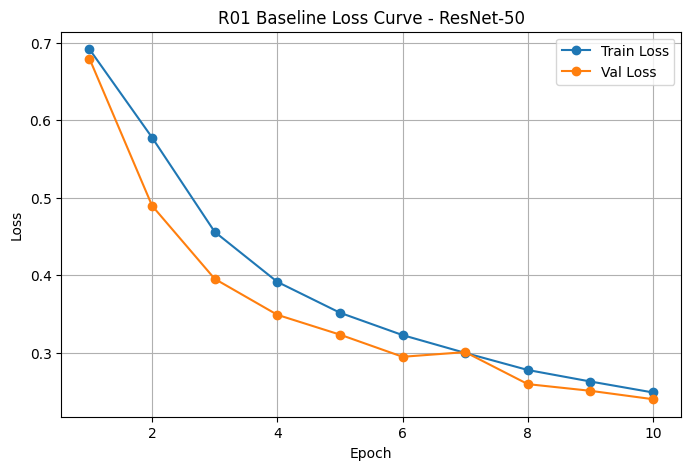

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R01 Baseline Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R01_baseline_loss_curve.png", bbox_inches="tight")
plt.show()

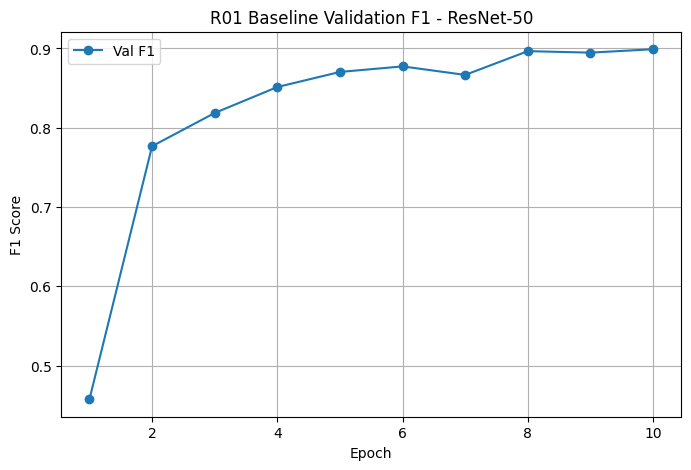

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R01 Baseline Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R01_baseline_val_f1.png", bbox_inches="tight")
plt.show()

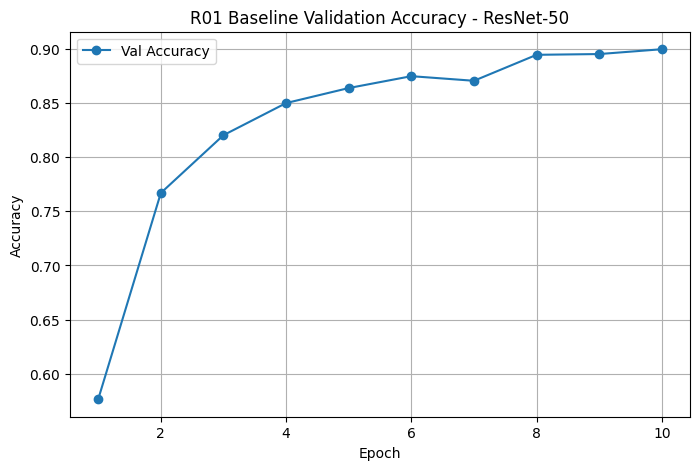

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R01 Baseline Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R01_baseline_val_accuracy.png", bbox_inches="tight")
plt.show()

## 16. Learning Rate Tuning

### 16.1 R02 Learning Rate = 1e-4

In [26]:
config = {
    "run_id": "R02",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "Adam",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "notes": "learning rate tuning: lr=1e-4",
}

In [27]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R02
Epoch 1/10 | Train Loss: 0.5409 | Val Loss: 0.4212 | Val F1: 0.7933
Epoch 2/10 | Train Loss: 0.3318 | Val Loss: 0.2387 | Val F1: 0.9024
Epoch 3/10 | Train Loss: 0.2170 | Val Loss: 0.2319 | Val F1: 0.8947
Epoch 4/10 | Train Loss: 0.1609 | Val Loss: 0.1623 | Val F1: 0.9345
Epoch 5/10 | Train Loss: 0.1269 | Val Loss: 0.1320 | Val F1: 0.9502
Epoch 6/10 | Train Loss: 0.1045 | Val Loss: 0.1088 | Val F1: 0.9561
Epoch 7/10 | Train Loss: 0.0897 | Val Loss: 0.1193 | Val F1: 0.9533
Epoch 8/10 | Train Loss: 0.0771 | Val Loss: 0.1176 | Val F1: 0.9561
Epoch 9/10 | Train Loss: 0.0693 | Val Loss: 0.0966 | Val F1: 0.9637
Epoch 10/10 | Train Loss: 0.0625 | Val Loss: 0.0832 | Val F1: 0.9691
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R02_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.540853,0.421198,0.81005,0.870209,0.7288,0.793252,0.907109
1,2,0.331783,0.238740,0.90220,0.900199,0.9047,0.902444,0.964526
2,3,0.216973,0.231886,0.90165,0.962464,0.8359,0.894728,0.980053
3,4,0.160898,0.162342,0.93570,0.951596,0.9181,0.934548,0.985366
4,5,0.126850,0.131985,0.94885,0.925329,0.9765,0.950226,0.990048
5,6,0.104472,0.108797,0.95685,0.972489,0.9403,0.956124,0.993850
6,7,0.089744,0.119319,0.95410,0.969209,0.9380,0.953349,0.992433
7,8,0.077107,0.117599,0.95665,0.968599,0.9439,0.956090,0.992649
8,9,0.069308,0.096583,0.96350,0.959366,0.9680,0.963664,0.994255
9,10,0.062511,0.083167,0.96900,0.965278,0.9730,0.969124,0.995518


In [28]:
run_result

{'run_id': 'R02',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'Adam',
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'val_loss': 0.08316713261197947,
 'val_accuracy': 0.969,
 'val_precision': 0.9652777777777778,
 'val_recall': 0.973,
 'val_f1': 0.9691235059760956,
 'val_roc_auc': 0.99551777,
 'best_epoch': 10,
 'train_time_min': 146.86840842962266,
 'checkpoint_saved': 'R02_best.pth',
 'notes': 'learning rate tuning: lr=1e-4'}

### 16.1.1 Save R02 History and Plots

In [29]:
history_path = results_dir / "R02_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R02_history.csv


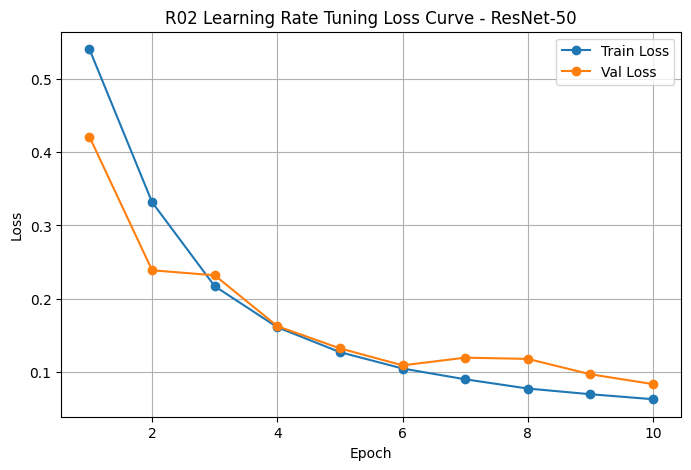

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R02 Learning Rate Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R02_loss_curve.png", bbox_inches="tight")
plt.show()

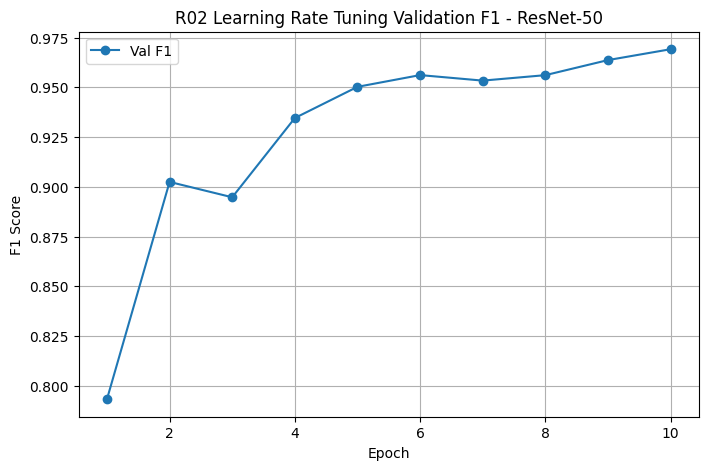

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R02 Learning Rate Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R02_val_f1.png", bbox_inches="tight")
plt.show()

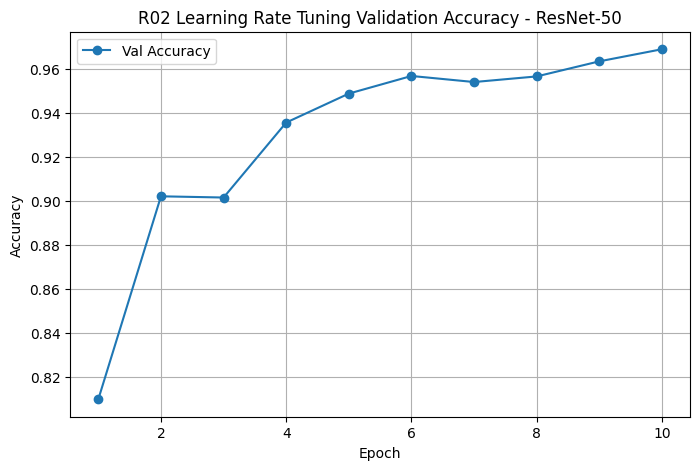

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R02 Learning Rate Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R02_val_accuracy.png", bbox_inches="tight")
plt.show()

### 16.2 R03 Learning Rate = 3e-4

In [33]:
config = {
    "run_id": "R03",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "Adam",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "notes": "learning rate tuning: lr=3e-4",
}

In [34]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R03
Epoch 1/10 | Train Loss: 0.5328 | Val Loss: 0.4076 | Val F1: 0.8169
Epoch 2/10 | Train Loss: 0.3399 | Val Loss: 0.2473 | Val F1: 0.9003
Epoch 3/10 | Train Loss: 0.2423 | Val Loss: 0.2115 | Val F1: 0.9157
Epoch 4/10 | Train Loss: 0.1931 | Val Loss: 0.1836 | Val F1: 0.9261
Epoch 5/10 | Train Loss: 0.1586 | Val Loss: 0.1374 | Val F1: 0.9457
Epoch 6/10 | Train Loss: 0.1383 | Val Loss: 0.1316 | Val F1: 0.9483
Epoch 7/10 | Train Loss: 0.1213 | Val Loss: 0.1346 | Val F1: 0.9497
Epoch 8/10 | Train Loss: 0.1092 | Val Loss: 0.1119 | Val F1: 0.9583
Epoch 9/10 | Train Loss: 0.1008 | Val Loss: 0.0941 | Val F1: 0.9659
Epoch 10/10 | Train Loss: 0.0948 | Val Loss: 0.1011 | Val F1: 0.9620
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R03_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.532771,0.407624,0.81840,0.823709,0.8102,0.816899,0.898527
1,2,0.339912,0.247324,0.89715,0.873296,0.9291,0.900334,0.961599
2,3,0.242290,0.211545,0.91395,0.897761,0.9343,0.915666,0.972315
3,4,0.193057,0.183642,0.92660,0.932745,0.9195,0.926075,0.979372
4,5,0.158585,0.137361,0.94570,0.945700,0.9457,0.945700,0.988382
5,6,0.138308,0.131624,0.94905,0.962223,0.9348,0.948313,0.990060
6,7,0.121288,0.134617,0.94980,0.950882,0.9486,0.949740,0.988496
7,8,0.109166,0.111948,0.95750,0.940921,0.9763,0.958284,0.992265
8,9,0.100770,0.094070,0.96590,0.966366,0.9654,0.965883,0.994547
9,10,0.094780,0.101067,0.96265,0.979977,0.9446,0.961963,0.995171


In [35]:
run_result

{'run_id': 'R03',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'val_loss': 0.09406996016888297,
 'val_accuracy': 0.9659,
 'val_precision': 0.9663663663663664,
 'val_recall': 0.9654,
 'val_f1': 0.9658829414707354,
 'val_roc_auc': 0.99454744,
 'best_epoch': 9,
 'train_time_min': 145.87989514668783,
 'checkpoint_saved': 'R03_best.pth',
 'notes': 'learning rate tuning: lr=3e-4'}

### 16.2.1 Save R03 History and Plots

In [36]:
history_path = results_dir / "R03_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R03_history.csv


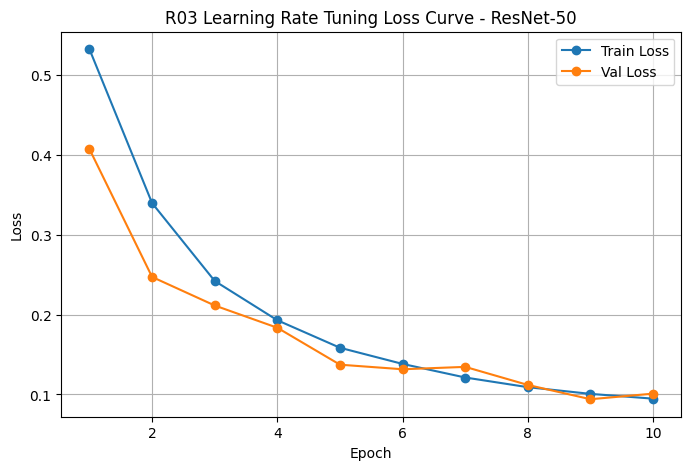

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R03 Learning Rate Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R03_loss_curve.png", bbox_inches="tight")
plt.show()

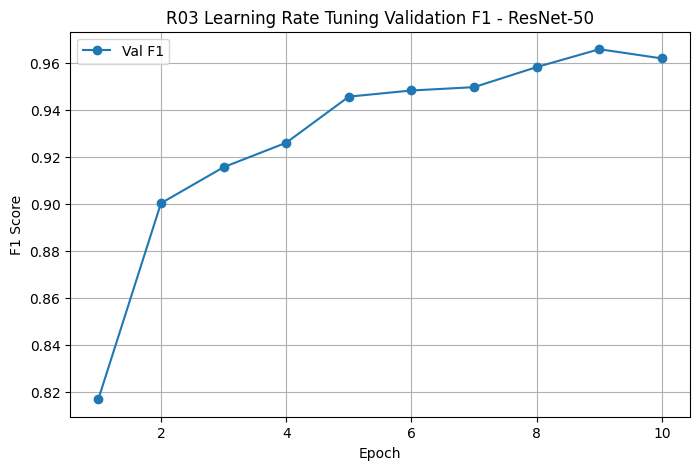

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R03 Learning Rate Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R03_val_f1.png", bbox_inches="tight")
plt.show()

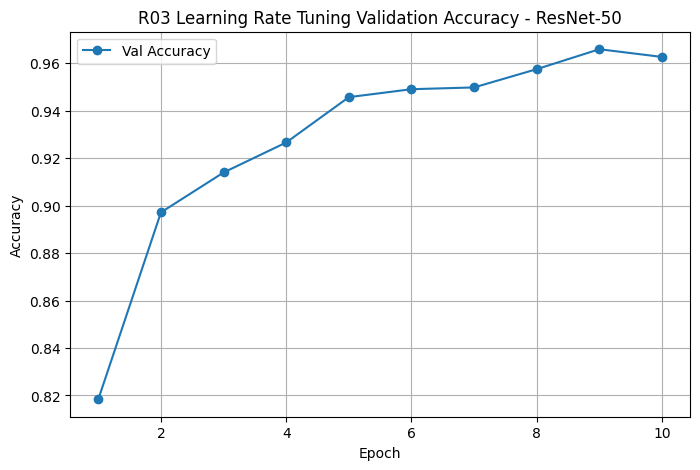

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R03 Learning Rate Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R03_val_accuracy.png", bbox_inches="tight")
plt.show()

## 17. Optimizer Tuning

### 17.1 R04 Optimizer = AdamW

In [15]:
config = {
    "run_id": "R04",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "notes": "optimizer tuning: AdamW with best lr=1e-4",
}

In [16]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R04
Epoch 1/10 | Train Loss: 0.5490 | Val Loss: 0.4268 | Val F1: 0.8270
Epoch 2/10 | Train Loss: 0.3329 | Val Loss: 0.2714 | Val F1: 0.8764
Epoch 3/10 | Train Loss: 0.2072 | Val Loss: 0.1809 | Val F1: 0.9266
Epoch 4/10 | Train Loss: 0.1453 | Val Loss: 0.1514 | Val F1: 0.9398
Epoch 5/10 | Train Loss: 0.1076 | Val Loss: 0.1126 | Val F1: 0.9580
Epoch 6/10 | Train Loss: 0.0874 | Val Loss: 0.1029 | Val F1: 0.9608
Epoch 7/10 | Train Loss: 0.0691 | Val Loss: 0.0889 | Val F1: 0.9672
Epoch 8/10 | Train Loss: 0.0580 | Val Loss: 0.0860 | Val F1: 0.9690
Epoch 9/10 | Train Loss: 0.0506 | Val Loss: 0.0930 | Val F1: 0.9688
Epoch 10/10 | Train Loss: 0.0434 | Val Loss: 0.0823 | Val F1: 0.9710
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R04_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.549031,0.426792,0.81865,0.790713,0.8667,0.826964,0.896009
1,2,0.332939,0.271382,0.88470,0.944637,0.8173,0.876367,0.968025
2,3,0.207241,0.180852,0.92820,0.947908,0.9062,0.926585,0.982011
3,4,0.145271,0.151370,0.93840,0.919120,0.9614,0.939785,0.986610
4,5,0.107622,0.112636,0.95840,0.966233,0.9500,0.958048,0.992390
5,6,0.087449,0.102945,0.96010,0.945057,0.9770,0.960763,0.994039
6,7,0.069070,0.088947,0.96715,0.965706,0.9687,0.967201,0.994755
7,8,0.058006,0.086044,0.96895,0.967967,0.9700,0.968983,0.995324
8,9,0.050595,0.092959,0.96825,0.952372,0.9858,0.968798,0.996287
9,10,0.043361,0.082343,0.97110,0.975474,0.9665,0.970966,0.996259


In [17]:
run_result

{'run_id': 'R04',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'val_loss': 0.08234260120059876,
 'val_accuracy': 0.9711,
 'val_precision': 0.9754743641501816,
 'val_recall': 0.9665,
 'val_f1': 0.9709664456499899,
 'val_roc_auc': 0.9962585350000001,
 'best_epoch': 10,
 'train_time_min': 147.26128470102947,
 'checkpoint_saved': 'R04_best.pth',
 'notes': 'optimizer tuning: AdamW with best lr=1e-4'}

### 17.1.1 Save R04 History and Plots

In [18]:
history_path = results_dir / "R04_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R04_history.csv


In [20]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


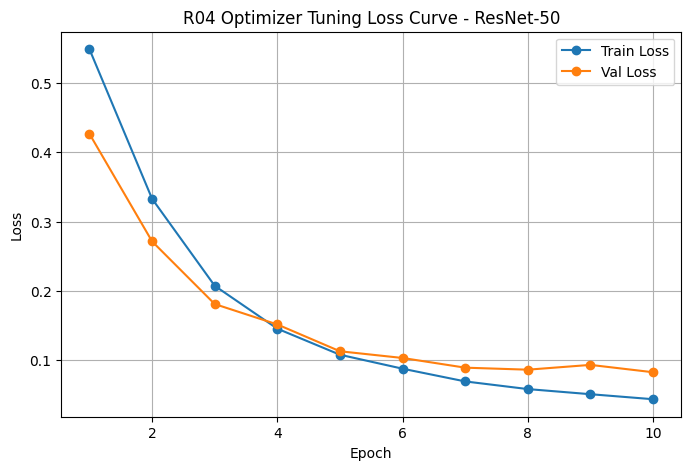

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R04 Optimizer Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R04_loss_curve.png", bbox_inches="tight")
plt.show()

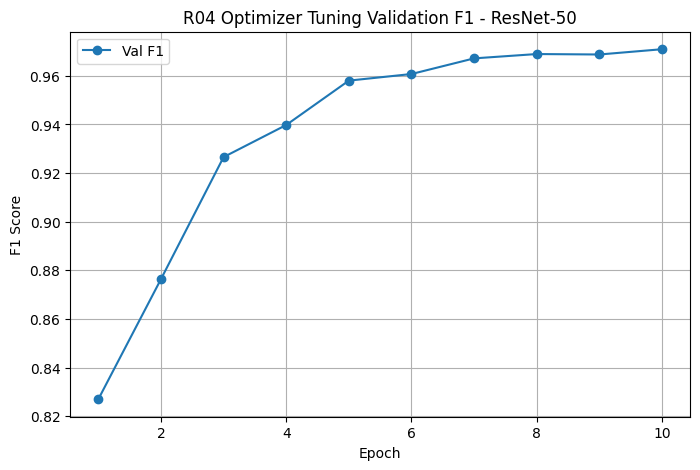

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R04 Optimizer Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R04_val_f1.png", bbox_inches="tight")
plt.show()

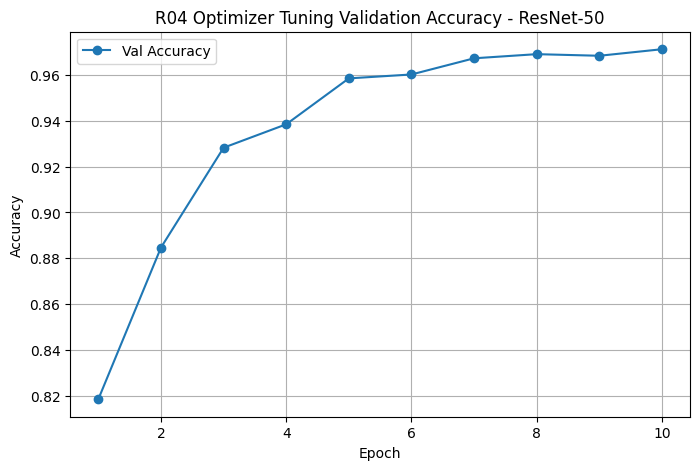

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R04 Optimizer Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R04_val_accuracy.png", bbox_inches="tight")
plt.show()

### 17.2 R05 Optimizer = SGD

In [24]:
config = {
    "run_id": "R05",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "SGD",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "notes": "optimizer tuning: SGD with best lr=1e-4",
}

In [25]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R05
Epoch 1/10 | Train Loss: 0.7139 | Val Loss: 0.6891 | Val F1: 0.3665
Epoch 2/10 | Train Loss: 0.6855 | Val Loss: 0.6355 | Val F1: 0.6226
Epoch 3/10 | Train Loss: 0.6432 | Val Loss: 0.6732 | Val F1: 0.7256
Epoch 4/10 | Train Loss: 0.5994 | Val Loss: 0.5817 | Val F1: 0.7444
Epoch 5/10 | Train Loss: 0.5515 | Val Loss: 0.4848 | Val F1: 0.7800
Epoch 6/10 | Train Loss: 0.5122 | Val Loss: 0.5227 | Val F1: 0.7911
Epoch 7/10 | Train Loss: 0.4766 | Val Loss: 0.4260 | Val F1: 0.7985
Epoch 8/10 | Train Loss: 0.4350 | Val Loss: 0.4172 | Val F1: 0.8080
Epoch 9/10 | Train Loss: 0.4004 | Val Loss: 0.3644 | Val F1: 0.8433
Epoch 10/10 | Train Loss: 0.3623 | Val Loss: 0.3482 | Val F1: 0.8670
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R05_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.713918,0.689076,0.56285,0.665351,0.2529,0.366495,0.634728
1,2,0.685548,0.635464,0.65185,0.679683,0.5744,0.622622,0.714617
2,3,0.643229,0.673241,0.67360,0.625907,0.8630,0.725576,0.750787
3,4,0.599393,0.581698,0.72615,0.697943,0.7974,0.744364,0.796899
4,5,0.551461,0.484834,0.77270,0.755720,0.8059,0.780004,0.849407
5,6,0.512155,0.522654,0.76905,0.722153,0.8746,0.791099,0.857069
6,7,0.476603,0.426025,0.80515,0.826608,0.7723,0.798532,0.890221
7,8,0.435048,0.417160,0.81805,0.855085,0.7659,0.808039,0.903101
8,9,0.400353,0.364443,0.84495,0.852313,0.8345,0.843313,0.920867
9,10,0.362284,0.348172,0.85970,0.824288,0.9143,0.866964,0.932938


In [26]:
run_result

{'run_id': 'R05',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'SGD',
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'val_loss': 0.34817203290089965,
 'val_accuracy': 0.8597,
 'val_precision': 0.8242877749729535,
 'val_recall': 0.9143,
 'val_f1': 0.8669637777356344,
 'val_roc_auc': 0.9329375299999999,
 'best_epoch': 10,
 'train_time_min': 142.120388174057,
 'checkpoint_saved': 'R05_best.pth',
 'notes': 'optimizer tuning: SGD with best lr=1e-4'}

### Save R05 History and Plots

In [27]:
history_path = results_dir / "R05_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R05_history.csv


In [28]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


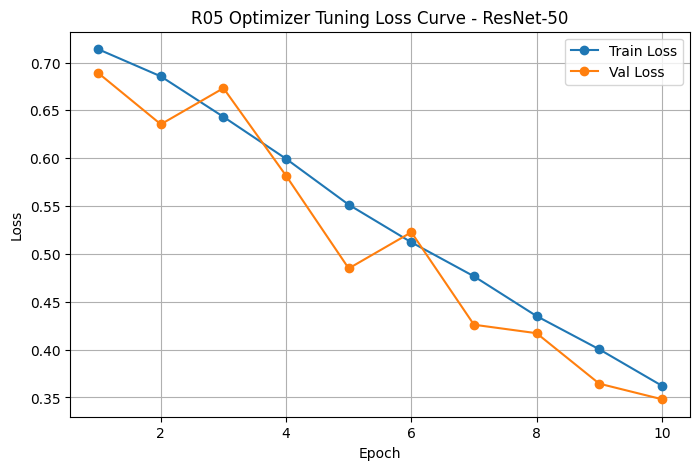

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R05 Optimizer Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R05_loss_curve.png", bbox_inches="tight")
plt.show()

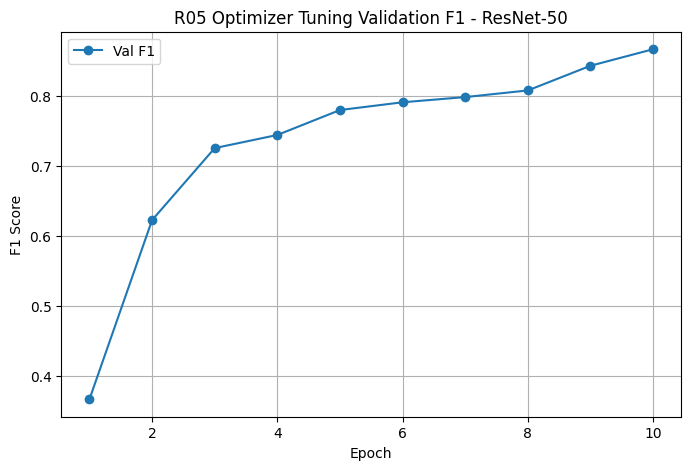

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R05 Optimizer Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R05_val_f1.png", bbox_inches="tight")
plt.show()

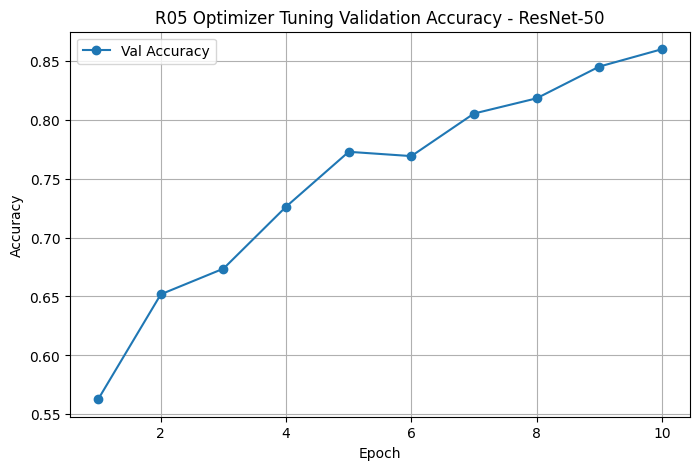

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R05 Optimizer Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R05_val_accuracy.png", bbox_inches="tight")
plt.show()

## 18. Weight Decay Tuning

### 18.1 R06 Weight Decay = 1e-5

In [14]:
config = {
    "run_id": "R06",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "augmentation": "light",
    "notes": "weight decay tuning: wd=1e-5 with best lr=1e-4 and optimizer=AdamW",
}

In [15]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R06
Epoch 1/10 | Train Loss: 0.5523 | Val Loss: 0.4142 | Val F1: 0.7995
Epoch 2/10 | Train Loss: 0.3265 | Val Loss: 0.2280 | Val F1: 0.9052
Epoch 3/10 | Train Loss: 0.2009 | Val Loss: 0.1583 | Val F1: 0.9396
Epoch 4/10 | Train Loss: 0.1422 | Val Loss: 0.1488 | Val F1: 0.9462
Epoch 5/10 | Train Loss: 0.1075 | Val Loss: 0.1182 | Val F1: 0.9532
Epoch 6/10 | Train Loss: 0.0847 | Val Loss: 0.1093 | Val F1: 0.9566
Epoch 7/10 | Train Loss: 0.0694 | Val Loss: 0.1022 | Val F1: 0.9625
Epoch 8/10 | Train Loss: 0.0586 | Val Loss: 0.0763 | Val F1: 0.9718
Epoch 9/10 | Train Loss: 0.0517 | Val Loss: 0.1001 | Val F1: 0.9607
Epoch 10/10 | Train Loss: 0.0445 | Val Loss: 0.0743 | Val F1: 0.9744
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R06_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.552312,0.414169,0.80950,0.843889,0.7595,0.799474,0.899200
1,2,0.326499,0.227991,0.90610,0.913712,0.8969,0.905228,0.968952
2,3,0.200918,0.158270,0.93845,0.922602,0.9572,0.939583,0.984609
3,4,0.142223,0.148750,0.94425,0.913833,0.9810,0.946226,0.989922
4,5,0.107509,0.118192,0.95405,0.970664,0.9364,0.953224,0.992406
5,6,0.084720,0.109342,0.95705,0.966235,0.9472,0.956623,0.993117
6,7,0.069430,0.102206,0.96240,0.959186,0.9659,0.962531,0.993190
7,8,0.058589,0.076317,0.97185,0.972559,0.9711,0.971829,0.996249
8,9,0.051734,0.100100,0.96145,0.980427,0.9417,0.960673,0.995315
9,10,0.044489,0.074299,0.97425,0.969694,0.9791,0.974374,0.996566


In [16]:
run_result

{'run_id': 'R06',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'weight_decay': 1e-05,
 'augmentation': 'light',
 'val_loss': 0.07429854883862717,
 'val_accuracy': 0.97425,
 'val_precision': 0.9696939685054967,
 'val_recall': 0.9791,
 'val_f1': 0.9743742847191124,
 'val_roc_auc': 0.9965664200000001,
 'best_epoch': 10,
 'train_time_min': 147.70903160969416,
 'checkpoint_saved': 'R06_best.pth',
 'notes': 'weight decay tuning: wd=1e-5 with best lr=1e-4 and optimizer=AdamW'}

### 13.1.1 Save R06 History and Plots

In [17]:
history_path = results_dir / "R06_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R06_history.csv


In [18]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


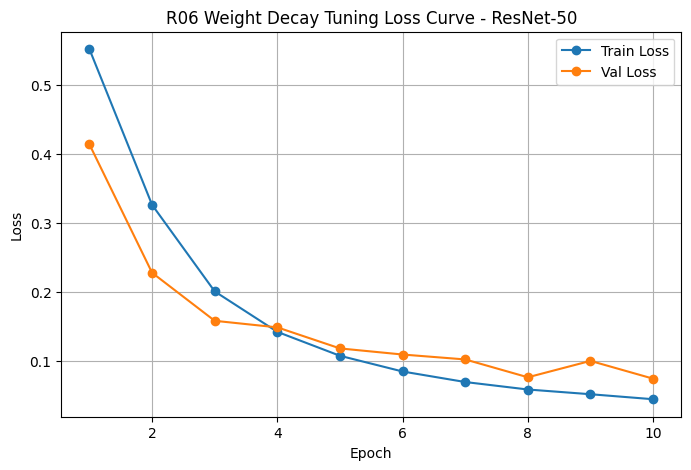

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R06 Weight Decay Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R06_loss_curve.png", bbox_inches="tight")
plt.show()

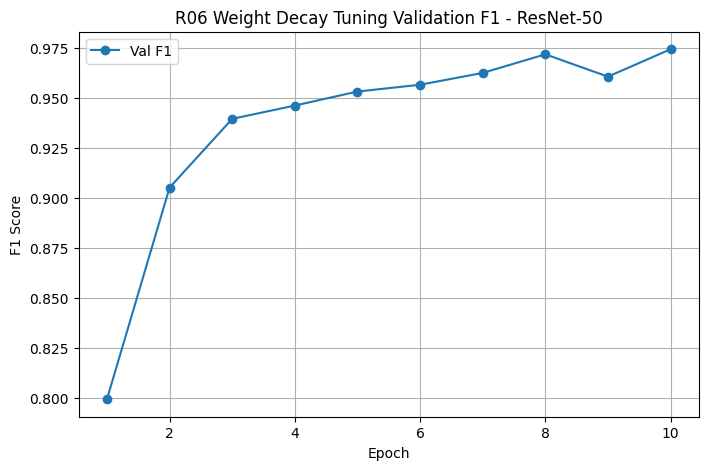

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R06 Weight Decay Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R06_val_f1.png", bbox_inches="tight")
plt.show()

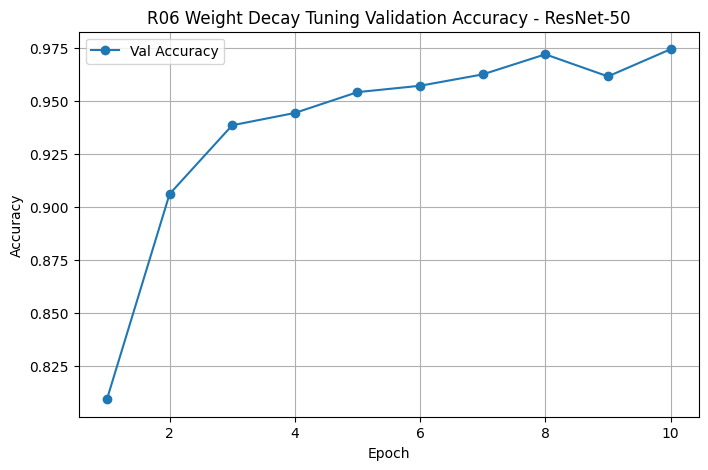

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R06 Weight Decay Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R06_val_accuracy.png", bbox_inches="tight")
plt.show()

### 18.2 R07 Weight Decay = 1e-4

In [22]:
config = {
    "run_id": "R07",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "notes": "weight decay tuning: wd=1e-4 with best lr=1e-4 and optimizer=AdamW",
}

In [23]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R07
Epoch 1/10 | Train Loss: 0.5510 | Val Loss: 0.4325 | Val F1: 0.7992
Epoch 2/10 | Train Loss: 0.3364 | Val Loss: 0.2778 | Val F1: 0.8834
Epoch 3/10 | Train Loss: 0.2134 | Val Loss: 0.2221 | Val F1: 0.9183
Epoch 4/10 | Train Loss: 0.1478 | Val Loss: 0.1622 | Val F1: 0.9337
Epoch 5/10 | Train Loss: 0.1099 | Val Loss: 0.1112 | Val F1: 0.9577
Epoch 6/10 | Train Loss: 0.0882 | Val Loss: 0.1084 | Val F1: 0.9592
Epoch 7/10 | Train Loss: 0.0720 | Val Loss: 0.0889 | Val F1: 0.9661
Epoch 8/10 | Train Loss: 0.0592 | Val Loss: 0.0891 | Val F1: 0.9686
Epoch 9/10 | Train Loss: 0.0515 | Val Loss: 0.0873 | Val F1: 0.9687
Epoch 10/10 | Train Loss: 0.0449 | Val Loss: 0.0746 | Val F1: 0.9719
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R07_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.550964,0.432468,0.80645,0.830191,0.7705,0.799232,0.889001
1,2,0.336446,0.277816,0.88550,0.900062,0.8673,0.883377,0.955801
2,3,0.213361,0.222099,0.91280,0.863765,0.9802,0.918306,0.981078
3,4,0.147809,0.162172,0.93580,0.965101,0.9043,0.933712,0.987639
4,5,0.109868,0.111239,0.95775,0.959727,0.9556,0.957659,0.992285
5,6,0.088155,0.108400,0.95830,0.938145,0.9813,0.959238,0.994078
6,7,0.071984,0.088850,0.96605,0.965538,0.9666,0.966069,0.994798
7,8,0.059241,0.089079,0.96815,0.955709,0.9818,0.968579,0.995512
8,9,0.051480,0.087307,0.96895,0.975464,0.9621,0.968736,0.995673
9,10,0.044889,0.074623,0.97200,0.973896,0.9700,0.971944,0.996471


In [24]:
run_result

{'run_id': 'R07',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'val_loss': 0.07462344659464125,
 'val_accuracy': 0.972,
 'val_precision': 0.9738955823293173,
 'val_recall': 0.97,
 'val_f1': 0.9719438877755511,
 'val_roc_auc': 0.996470665,
 'best_epoch': 10,
 'train_time_min': 146.8923613468806,
 'checkpoint_saved': 'R07_best.pth',
 'notes': 'weight decay tuning: wd=1e-4 with best lr=1e-4 and optimizer=AdamW'}

### 18.2.1 Save R07 History and Plots

In [25]:
history_path = results_dir / "R07_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R07_history.csv


In [26]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


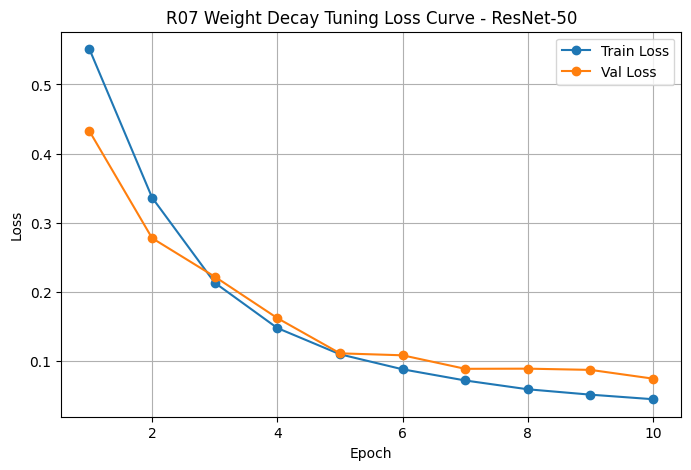

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R07 Weight Decay Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R07_loss_curve.png", bbox_inches="tight")
plt.show()

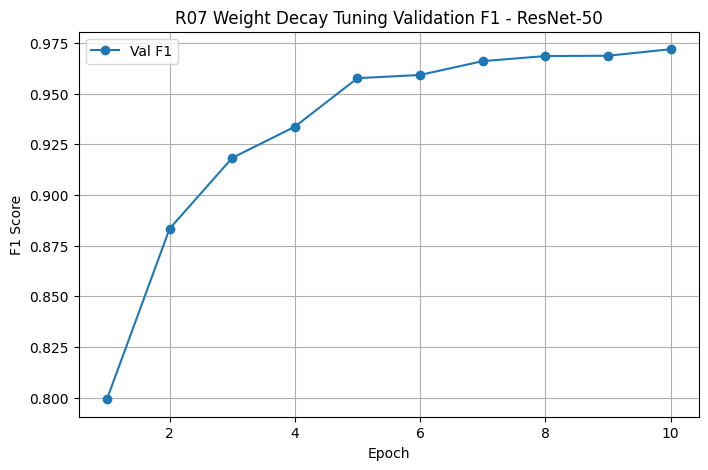

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R07 Weight Decay Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R07_val_f1.png", bbox_inches="tight")
plt.show()

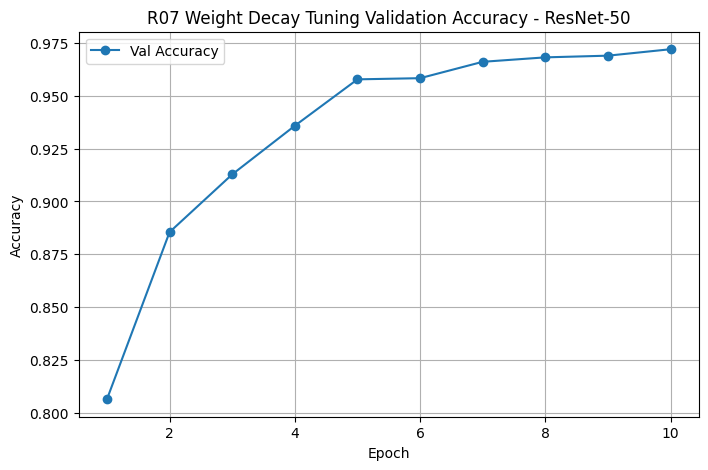

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R07 Weight Decay Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R07_val_accuracy.png", bbox_inches="tight")
plt.show()

### 18.3 R08 Weight Decay = 1e-3

In [30]:
config = {
    "run_id": "R08",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-3,
    "augmentation": "light",
    "notes": "weight decay tuning: wd=1e-3 with best lr=1e-4 and optimizer=AdamW",
}

In [31]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R08
Epoch 1/10 | Train Loss: 0.5471 | Val Loss: 0.4641 | Val F1: 0.7672
Epoch 2/10 | Train Loss: 0.3328 | Val Loss: 0.2584 | Val F1: 0.8988
Epoch 3/10 | Train Loss: 0.2068 | Val Loss: 0.1866 | Val F1: 0.9214
Epoch 4/10 | Train Loss: 0.1455 | Val Loss: 0.1326 | Val F1: 0.9503
Epoch 5/10 | Train Loss: 0.1098 | Val Loss: 0.1258 | Val F1: 0.9516
Epoch 6/10 | Train Loss: 0.0858 | Val Loss: 0.0990 | Val F1: 0.9633
Epoch 7/10 | Train Loss: 0.0716 | Val Loss: 0.1061 | Val F1: 0.9598
Epoch 8/10 | Train Loss: 0.0606 | Val Loss: 0.0858 | Val F1: 0.9679
Epoch 9/10 | Train Loss: 0.0512 | Val Loss: 0.0988 | Val F1: 0.9640
Epoch 10/10 | Train Loss: 0.0444 | Val Loss: 0.0749 | Val F1: 0.9745
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R08_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.547134,0.464061,0.79125,0.866952,0.6881,0.767241,0.894523
1,2,0.332755,0.258434,0.89355,0.856509,0.9455,0.898807,0.962787
2,3,0.206795,0.186562,0.92355,0.947585,0.8967,0.921441,0.981163
3,4,0.145508,0.132555,0.94925,0.930192,0.9714,0.950350,0.989424
4,5,0.109782,0.125788,0.95135,0.946042,0.9573,0.951638,0.990039
5,6,0.085805,0.098971,0.96325,0.961634,0.9650,0.963314,0.993861
6,7,0.071649,0.106055,0.95995,0.963332,0.9563,0.959803,0.993207
7,8,0.060586,0.085843,0.96795,0.969123,0.9667,0.967910,0.995545
8,9,0.051181,0.098808,0.96475,0.984771,0.9441,0.964007,0.996331
9,10,0.044407,0.074883,0.97430,0.966463,0.9827,0.974514,0.996844


In [32]:
run_result

{'run_id': 'R08',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'weight_decay': 0.001,
 'augmentation': 'light',
 'val_loss': 0.07488308665716163,
 'val_accuracy': 0.9743,
 'val_precision': 0.9664634146341463,
 'val_recall': 0.9827,
 'val_f1': 0.9745140817136058,
 'val_roc_auc': 0.9968442750000001,
 'best_epoch': 10,
 'train_time_min': 146.7920928676923,
 'checkpoint_saved': 'R08_best.pth',
 'notes': 'weight decay tuning: wd=1e-3 with best lr=1e-4 and optimizer=AdamW'}

### 18.3.1 Save R08 History and Plots

In [33]:
history_path = results_dir / "R08_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R08_history.csv


In [34]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


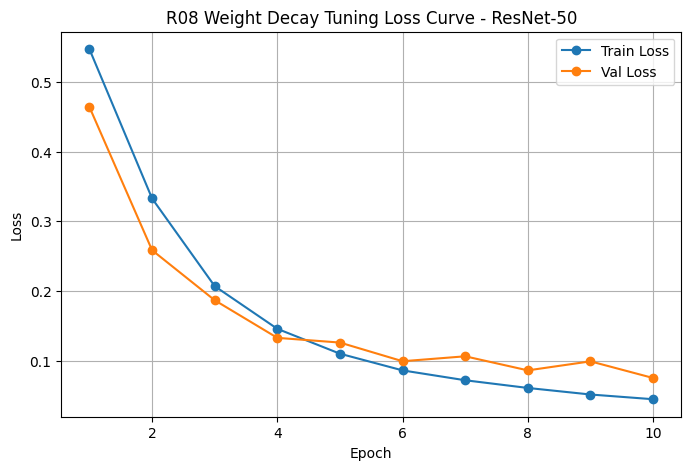

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R08 Weight Decay Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R08_loss_curve.png", bbox_inches="tight")
plt.show()

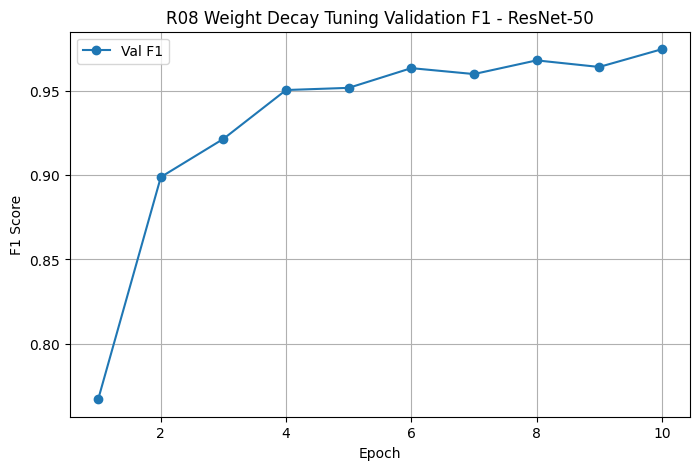

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R08 Weight Decay Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R08_val_f1.png", bbox_inches="tight")
plt.show()

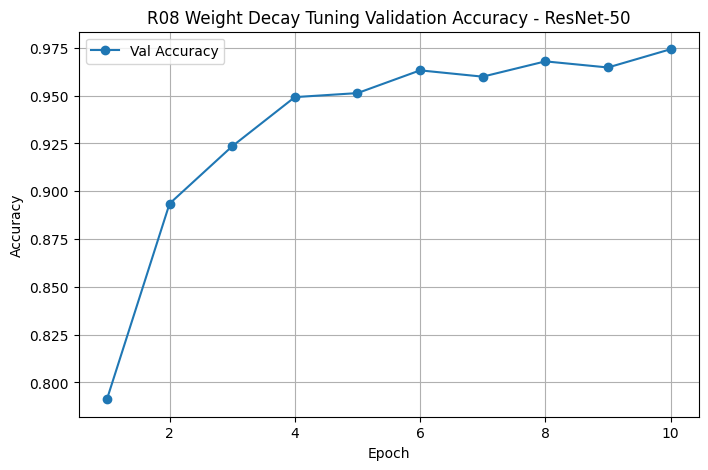

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R08 Weight Decay Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R08_val_accuracy.png", bbox_inches="tight")
plt.show()

## 19. Augmentation Tuning
Augmentation can help with in-domain validation performance and cross-dataset generalization
We can skip light augmentation since the current setup used it before.

### 19.0 Augmentation Definitions

In [15]:
input_size = 224

light_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

medium_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

strong_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    transforms.RandomRotation(15),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

### 19.0.1 Dataloader Builder for Augmentation Tuning

In [16]:
def get_dataloaders(augmentation_name, batch_size=8):
    if augmentation_name == "light":
        train_transform = light_transform
    elif augmentation_name == "medium":
        train_transform = medium_transform
    elif augmentation_name == "strong":
        train_transform = strong_transform
    else:
        raise ValueError("Unsupported augmentation setting")

    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    return train_loader, val_loader

##### Make sure to update the run_experiment(config)  with the new augmention line
train_loader, val_loader = get_dataloaders(config["augmentation"], batch_size=batch_size)

The function should looke like this:
def run_experiment(config):
    print(f"Starting run: {config['run_id']}")
    train_loader, val_loader = get_dataloaders(config["augmentation"], batch_size=batch_size)

    model = get_resnet50(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()

### 19.1 R10 Augmentation = medium

In [17]:
config = {
    "run_id": "R10",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-3,
    "augmentation": "medium",
    "notes": "augmentation tuning: medium with best lr=1e-4, optimizer=AdamW, wd=1e-3",
}

In [18]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R10
Epoch 1/10 | Train Loss: 0.6010 | Val Loss: 0.5030 | Val F1: 0.7391
Epoch 2/10 | Train Loss: 0.4148 | Val Loss: 0.3551 | Val F1: 0.8304
Epoch 3/10 | Train Loss: 0.2917 | Val Loss: 0.2255 | Val F1: 0.9049
Epoch 4/10 | Train Loss: 0.2231 | Val Loss: 0.1828 | Val F1: 0.9296
Epoch 5/10 | Train Loss: 0.1782 | Val Loss: 0.2084 | Val F1: 0.9119
Epoch 6/10 | Train Loss: 0.1488 | Val Loss: 0.1427 | Val F1: 0.9417
Epoch 7/10 | Train Loss: 0.1281 | Val Loss: 0.1207 | Val F1: 0.9539
Epoch 8/10 | Train Loss: 0.1118 | Val Loss: 0.1078 | Val F1: 0.9606
Epoch 9/10 | Train Loss: 0.0996 | Val Loss: 0.0923 | Val F1: 0.9651
Epoch 10/10 | Train Loss: 0.0889 | Val Loss: 0.0931 | Val F1: 0.9659
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R10_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.601034,0.503007,0.76045,0.811431,0.6786,0.739095,0.849276
1,2,0.414750,0.355098,0.84340,0.905622,0.7667,0.830391,0.936774
2,3,0.291706,0.225455,0.90745,0.930299,0.8809,0.904926,0.971517
3,4,0.223104,0.182842,0.92795,0.908388,0.9519,0.929635,0.980225
4,5,0.178191,0.208437,0.91680,0.969475,0.8607,0.911855,0.984425
5,6,0.148819,0.142691,0.94350,0.972814,0.9125,0.941692,0.991450
6,7,0.128088,0.120722,0.95320,0.940256,0.9679,0.953878,0.991784
7,8,0.111779,0.107832,0.96005,0.947650,0.9739,0.960596,0.992968
8,9,0.099595,0.092307,0.96530,0.971715,0.9585,0.965062,0.994905
9,10,0.088881,0.093135,0.96600,0.969853,0.9619,0.965860,0.994718


In [19]:
run_result

{'run_id': 'R10',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'weight_decay': 0.001,
 'augmentation': 'medium',
 'val_loss': 0.09313486356364083,
 'val_accuracy': 0.966,
 'val_precision': 0.9698527929017947,
 'val_recall': 0.9619,
 'val_f1': 0.9658600261070388,
 'val_roc_auc': 0.9947181799999999,
 'best_epoch': 10,
 'train_time_min': 147.1709903915723,
 'checkpoint_saved': 'R10_best.pth',
 'notes': 'augmentation tuning: medium with best lr=1e-4, optimizer=AdamW, wd=1e-3'}

### 19.1.1 Save R10 History and Plots### 19.1.1 Save R10 History and Plots

In [20]:
history_path = results_dir / "R10_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R10_history.csv


In [21]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


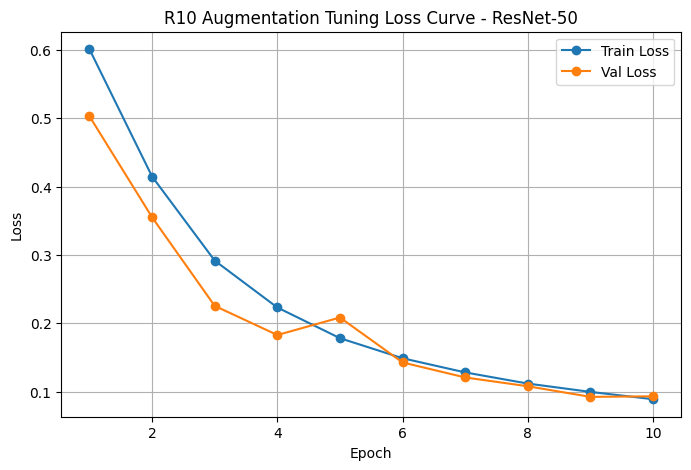

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R10 Augmentation Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R10_loss_curve.png", bbox_inches="tight")
plt.show()

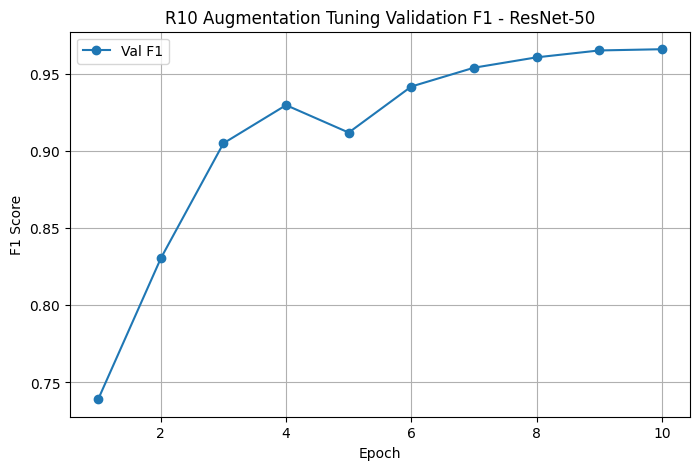

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R10 Augmentation Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R10_val_f1.png", bbox_inches="tight")
plt.show()

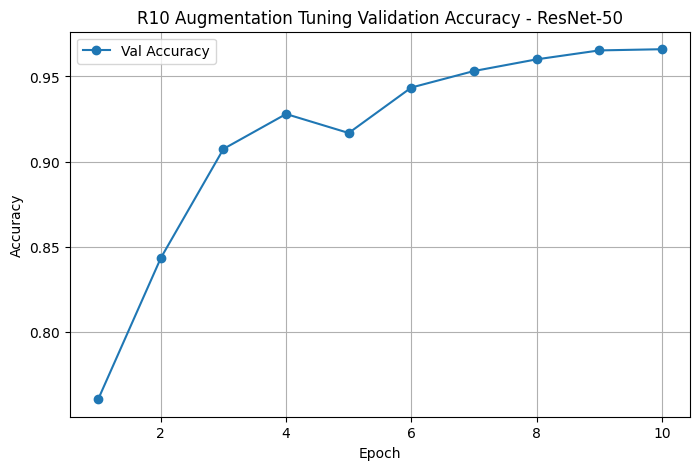

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R10 Augmentation Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R10_val_accuracy.png", bbox_inches="tight")
plt.show()

### 19.2 R11 Augmentation = strong

In [25]:
config = {
    "run_id": "R11",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-3,
    "augmentation": "strong",
    "notes": "augmentation tuning: strong with best lr=1e-4, optimizer=AdamW, wd=1e-3",
}

In [26]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R11
Epoch 1/10 | Train Loss: 0.6300 | Val Loss: 0.5294 | Val F1: 0.7122
Epoch 2/10 | Train Loss: 0.4597 | Val Loss: 0.4446 | Val F1: 0.8336
Epoch 3/10 | Train Loss: 0.3458 | Val Loss: 0.3133 | Val F1: 0.8859
Epoch 4/10 | Train Loss: 0.2718 | Val Loss: 0.2322 | Val F1: 0.9142
Epoch 5/10 | Train Loss: 0.2249 | Val Loss: 0.2587 | Val F1: 0.9230
Epoch 6/10 | Train Loss: 0.1888 | Val Loss: 0.2560 | Val F1: 0.9357
Epoch 7/10 | Train Loss: 0.1625 | Val Loss: 0.4276 | Val F1: 0.9361
Epoch 8/10 | Train Loss: 0.1451 | Val Loss: 0.1339 | Val F1: 0.9494
Epoch 9/10 | Train Loss: 0.1299 | Val Loss: 0.1646 | Val F1: 0.9412
Epoch 10/10 | Train Loss: 0.1178 | Val Loss: 0.1999 | Val F1: 0.9442
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R11_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.630034,0.529365,0.74080,0.800474,0.6415,0.712224,0.835421
1,2,0.459680,0.444630,0.81385,0.753657,0.9325,0.833594,0.907131
2,3,0.345777,0.313322,0.88440,0.874367,0.8978,0.885929,0.946960
3,4,0.271819,0.232171,0.91280,0.899381,0.9296,0.914241,0.968164
4,5,0.224911,0.258722,0.92105,0.900504,0.9467,0.923024,0.964771
5,6,0.188769,0.256032,0.93545,0.932123,0.9393,0.935698,0.975337
6,7,0.162536,0.427564,0.93355,0.900953,0.9742,0.936146,0.964091
7,8,0.145118,0.133931,0.94885,0.940006,0.9589,0.949359,0.988750
8,9,0.129896,0.164636,0.94290,0.969871,0.9142,0.941213,0.988093
9,10,0.117768,0.199869,0.94605,0.977518,0.9131,0.944212,0.985518


In [42]:
log_df = pd.read_csv(results_dir / "experiment_log.csv")
log_df[log_df["run_id"] == "R11"]

,run_id,model,run_type,batch_size,epochs,optimizer,learning_rate,weight_decay,augmentation,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,best_epoch,train_time_min,checkpoint_saved,notes
10,R11,ResNet-50,tuning,8,10,AdamW,0.0001,0.001,strong,0.133931,0.94885,0.940006,0.9589,0.949359,0.98875,8,146.956355,R11_best.pth,"augmentation tuning: strong with best lr=1e-4,..."


In [43]:
log_df = pd.read_csv(results_dir / "experiment_log.csv")
r11_row = log_df[log_df["run_id"] == "R11"].iloc[0]
r11_row

run_id                                                            R11
model                                                       ResNet-50
run_type                                                       tuning
batch_size                                                          8
epochs                                                             10
optimizer                                                       AdamW
learning_rate                                                  0.0001
weight_decay                                                    0.001
augmentation                                                   strong
val_loss                                                     0.133931
val_accuracy                                                  0.94885
val_precision                                                0.940006
val_recall                                                     0.9589
val_f1                                                       0.949359
val_roc_auc         

### 19.2.1 Save R11 History and Plots

In [27]:
history_path = results_dir / "R11_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R11_history.csv


In [28]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


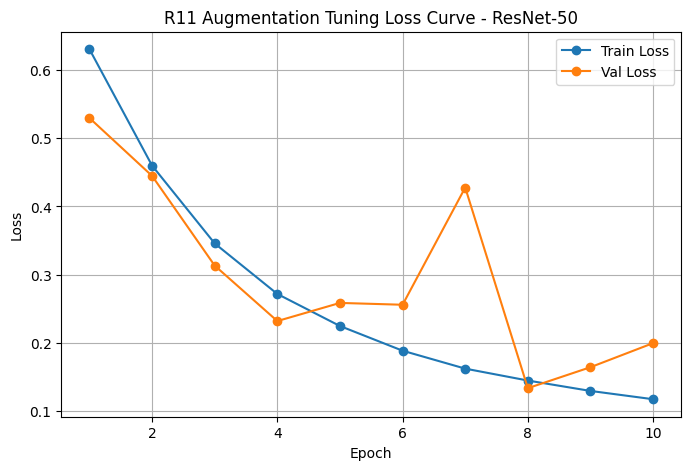

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R11 Augmentation Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R11_loss_curve.png", bbox_inches="tight")
plt.show()

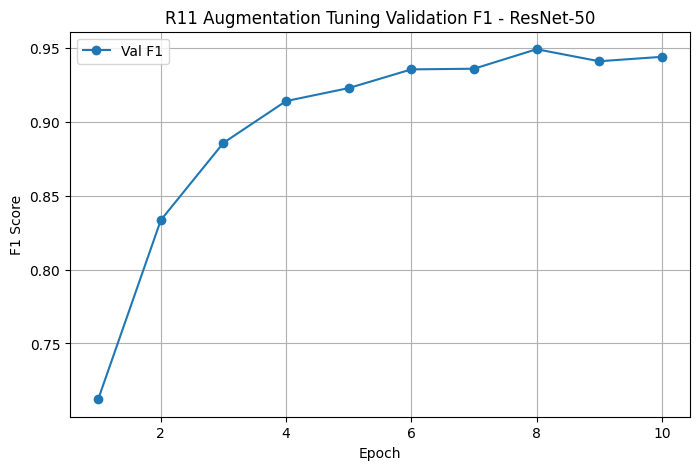

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R11 Augmentation Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R11_val_f1.png", bbox_inches="tight")
plt.show()

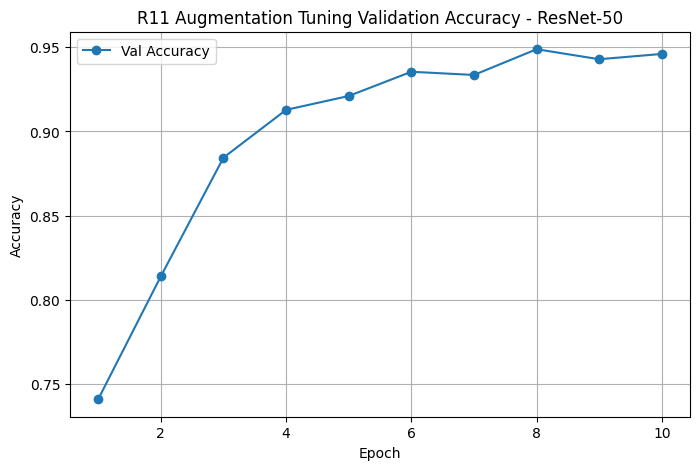

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R11 Augmentation Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R11_val_accuracy.png", bbox_inches="tight")
plt.show()

## 21. Batch Size Tuning

### Experiment Runner Update Note

The experiment runner was updated so that `batch_size` is now read from the `config` dictionary instead of using a fixed global value.

This allows later tuning runs to change batch size directly in the run configuration without rewriting the training pipeline.

Updated behavior:
- dataloaders now use `config["batch_size"]`
- saved run results now record `config["batch_size"]`

### 21.1 R12 Batch Size = 16

In [16]:
config = {
    "run_id": "R12",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-3,
    "augmentation": "light",
    "batch_size": 16,
    "notes": "batch size tuning: batch_size=16 with best lr=1e-4, optimizer=AdamW, wd=1e-3, augmentation=light",
}

In [17]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R12
Using augmentation: light
Using batch size: 16
Epoch 1/10 | Train Loss: 0.5606 | Val Loss: 0.4602 | Val F1: 0.8061
Epoch 2/10 | Train Loss: 0.3746 | Val Loss: 0.2917 | Val F1: 0.8815
Epoch 3/10 | Train Loss: 0.2435 | Val Loss: 0.2138 | Val F1: 0.9164
Epoch 4/10 | Train Loss: 0.1661 | Val Loss: 0.1570 | Val F1: 0.9416
Epoch 5/10 | Train Loss: 0.1207 | Val Loss: 0.1198 | Val F1: 0.9531
Epoch 6/10 | Train Loss: 0.0927 | Val Loss: 0.1535 | Val F1: 0.9371
Epoch 7/10 | Train Loss: 0.0741 | Val Loss: 0.0945 | Val F1: 0.9634
Epoch 8/10 | Train Loss: 0.0626 | Val Loss: 0.0976 | Val F1: 0.9658
Epoch 9/10 | Train Loss: 0.0513 | Val Loss: 0.0870 | Val F1: 0.9699
Epoch 10/10 | Train Loss: 0.0466 | Val Loss: 0.0755 | Val F1: 0.9723
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R12_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.560605,0.460246,0.78655,0.738494,0.8873,0.806087,0.881306
1,2,0.374609,0.291657,0.87715,0.851393,0.9138,0.881493,0.949934
2,3,0.243513,0.213754,0.91280,0.880181,0.9557,0.916387,0.974954
3,4,0.166050,0.157037,0.94045,0.924448,0.9593,0.941552,0.984974
4,5,0.120666,0.119763,0.95310,0.953281,0.9529,0.953091,0.991073
5,6,0.092745,0.153456,0.93975,0.980759,0.8971,0.937066,0.992472
6,7,0.074092,0.094516,0.96360,0.968851,0.9580,0.963395,0.994554
7,8,0.062642,0.097634,0.96535,0.952543,0.9795,0.965833,0.994678
8,9,0.051346,0.087026,0.97010,0.975040,0.9649,0.969944,0.995640
9,10,0.046603,0.075545,0.97240,0.976306,0.9683,0.972286,0.996589


In [18]:
run_result

{'run_id': 'R12',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 16,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'weight_decay': 0.001,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.07554522444735048,
 'val_accuracy': 0.9724,
 'val_precision': 0.9763057067957249,
 'val_recall': 0.9683,
 'val_f1': 0.9722863741339491,
 'val_roc_auc': 0.99658944,
 'best_epoch': 10,
 'train_time_min': 126.36251575152079,
 'checkpoint_saved': 'R12_best.pth',
 'notes': 'batch size tuning: batch_size=16 with best lr=1e-4, optimizer=AdamW, wd=1e-3, augmentation=light'}

### 21.1.1 Save R12 History and Plots

In [19]:
history_path = results_dir / "R12_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R12_history.csv


In [20]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


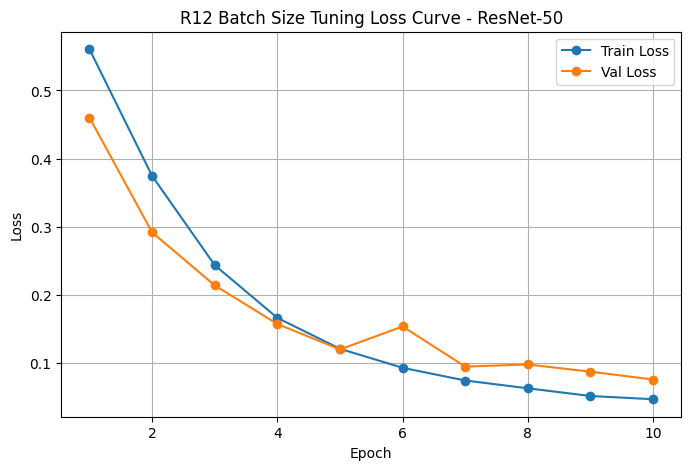

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R12 Batch Size Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R12_loss_curve.png", bbox_inches="tight")
plt.show()

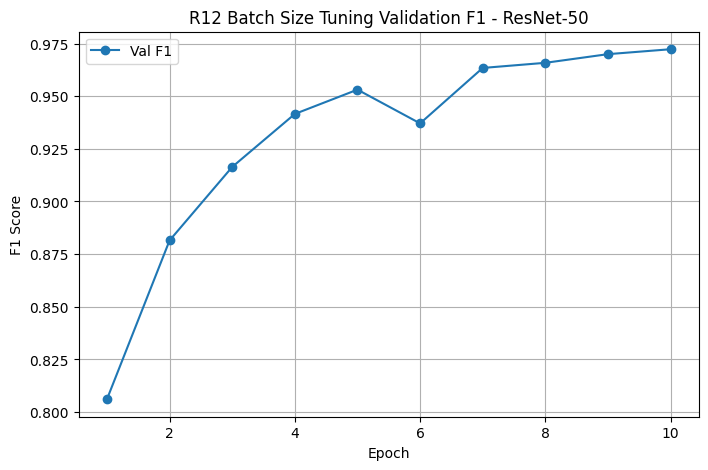

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R12 Batch Size Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R12_val_f1.png", bbox_inches="tight")
plt.show()

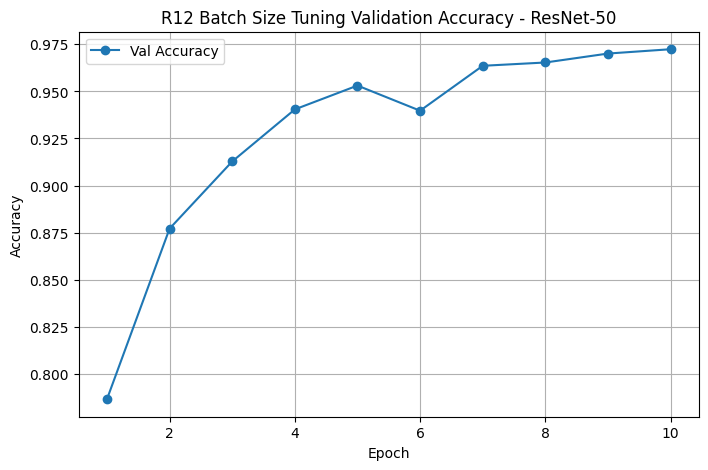

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R12 Batch Size Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R12_val_accuracy.png", bbox_inches="tight")
plt.show()

## 22. Scheduler Tuning

### Scheduler Tuning Note

The current best ResNet-50 configuration without a scheduler is treated as the reference setting for this stage.

A new experiment will test whether adding `ReduceLROnPlateau` improves validation performance.

### 22.1 R13 Scheduler = ReduceLROnPlateau

In [24]:
config = {
    "run_id": "R13",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 1e-4,
    "weight_decay": 1e-3,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "ReduceLROnPlateau",
    "notes": "scheduler tuning: ReduceLROnPlateau with best lr=1e-4, optimizer=AdamW, wd=1e-3, augmentation=light, batch_size=8",
}

In [25]:
history_df, run_result = run_experiment(config)
history_df

Starting run: R13
Using augmentation: light
Using batch size: 8
Epoch 1/10 | Train Loss: 0.5378 | Val Loss: 0.4139 | Val F1: 0.7963
Epoch 2/10 | Train Loss: 0.3166 | Val Loss: 0.2275 | Val F1: 0.9044
Epoch 3/10 | Train Loss: 0.1961 | Val Loss: 0.1609 | Val F1: 0.9364
Epoch 4/10 | Train Loss: 0.1377 | Val Loss: 0.1185 | Val F1: 0.9551
Epoch 5/10 | Train Loss: 0.1046 | Val Loss: 0.1350 | Val F1: 0.9462
Epoch 6/10 | Train Loss: 0.0835 | Val Loss: 0.1167 | Val F1: 0.9565
Epoch 7/10 | Train Loss: 0.0683 | Val Loss: 0.0848 | Val F1: 0.9694
Epoch 8/10 | Train Loss: 0.0595 | Val Loss: 0.0893 | Val F1: 0.9671
Epoch 9/10 | Train Loss: 0.0495 | Val Loss: 0.1102 | Val F1: 0.9633
Epoch 10/10 | Train Loss: 0.0235 | Val Loss: 0.0598 | Val F1: 0.9790
Saved results to C:\Users\Richa\anaconda_projects\results\experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\R13_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.537801,0.413857,0.81260,0.872231,0.7325,0.796282,0.906548
1,2,0.316596,0.227503,0.90665,0.926303,0.8836,0.904448,0.970949
2,3,0.196131,0.160857,0.93630,0.934995,0.9378,0.936395,0.983845
3,4,0.137728,0.118525,0.95555,0.964137,0.9463,0.955135,0.991933
4,5,0.104582,0.135033,0.94770,0.974258,0.9197,0.946193,0.992383
5,6,0.083520,0.116738,0.95505,0.927076,0.9878,0.956475,0.993758
6,7,0.068309,0.084760,0.96925,0.965942,0.9728,0.969359,0.995399
7,8,0.059545,0.089332,0.96680,0.959178,0.9751,0.967073,0.994876
8,9,0.049521,0.110238,0.96230,0.937701,0.9904,0.963330,0.995843
9,10,0.023514,0.059758,0.97900,0.977853,0.9802,0.979025,0.998022


In [26]:
run_result

{'run_id': 'R13',
 'model': 'ResNet-50',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0001,
 'weight_decay': 0.001,
 'augmentation': 'light',
 'scheduler': 'ReduceLROnPlateau',
 'val_loss': 0.05975774798369208,
 'val_accuracy': 0.979,
 'val_precision': 0.977853152434158,
 'val_recall': 0.9802,
 'val_f1': 0.9790251697962445,
 'val_roc_auc': 0.9980216849999999,
 'best_epoch': 10,
 'train_time_min': 147.34288325309754,
 'checkpoint_saved': 'R13_best.pth',
 'notes': 'scheduler tuning: ReduceLROnPlateau with best lr=1e-4, optimizer=AdamW, wd=1e-3, augmentation=light, batch_size=8'}

### 22.1.1 Save R13 History and Plots

In [27]:
history_path = results_dir / "R13_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\R13_history.csv


In [28]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


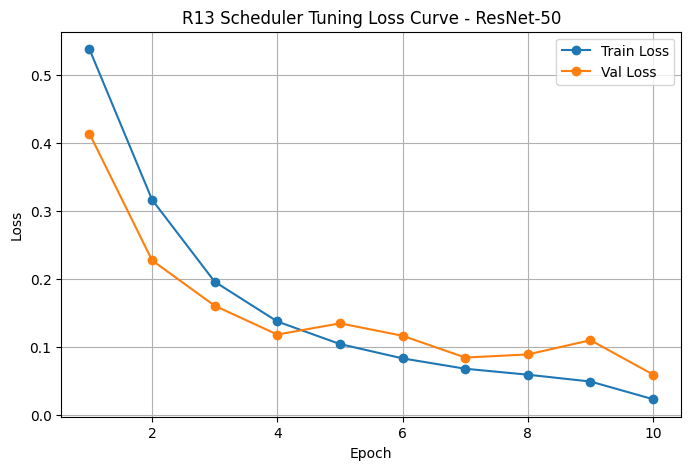

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("R13 Scheduler Tuning Loss Curve - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R13_loss_curve.png", bbox_inches="tight")
plt.show()

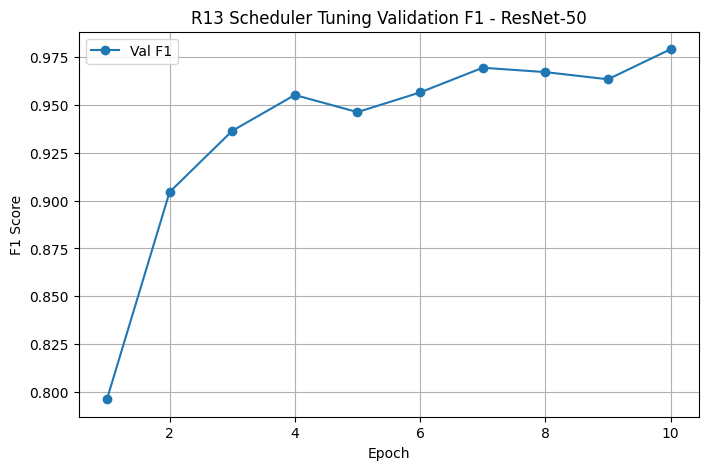

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("R13 Scheduler Tuning Validation F1 - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R13_val_f1.png", bbox_inches="tight")
plt.show()

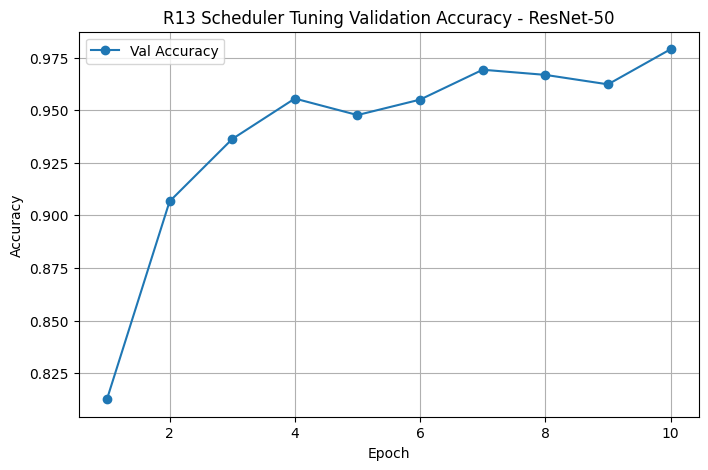

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("R13 Scheduler Tuning Validation Accuracy - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "R13_val_accuracy.png", bbox_inches="tight")
plt.show()

## 23. Best ResNet-50 Configuration Summary

Best configuration after tuning:

- Learning rate: 1e-4
- Optimizer: AdamW
- Weight decay: 1e-3
- Augmentation: light
- Batch size: 8
- Scheduler: ReduceLROnPlateau
- Epochs: 10
- Patience: 3

Best validation reference run:

- R13

## 24. Tuning Conclusions

Best settings found during tuning:

- Learning rate: 1e-4
- Optimizer: AdamW
- Weight decay: 1e-3
- Augmentation: light
- Batch size: 8
- Scheduler: ReduceLROnPlateau

Main observations:

- Lower learning rate improved validation performance compared with 1e-3.
- AdamW performed slightly better than Adam.
- Weight decay of 1e-3 produced the strongest regularization result.
- Stronger augmentation reduced validation performance.
- Increasing batch size to 16 did not improve results.
- ReduceLROnPlateau improved validation F1 and became the final selected scheduler setting.

## 25. Final Evaluation Note

Hyperparameter tuning for ResNet-50 is complete.

The following stages will now be performed using the final selected configuration:
- held-out test split evaluation
- unseen dataset evaluation

No further tuning should be done using the test split.

## 26. Tuning Comparison Table

In [32]:
comparison_data = [
    {
        "Tuning Stage": "Learning Rate",
        "Selected Run": "R02",
        "Compared Setting": "learning_rate",
        "Chosen Value": "1e-4",
        "Val Loss": 0.083167,
        "Val Accuracy": 0.9690,
        "Val F1": 0.969124,
        "Val ROC-AUC": 0.995518,
        "Best Epoch": 10,
        "Notes": "Best LR among 1e-3, 1e-4, 3e-4"
    },
    {
        "Tuning Stage": "Optimizer",
        "Selected Run": "R04",
        "Compared Setting": "optimizer",
        "Chosen Value": "AdamW",
        "Val Loss": 0.082343,
        "Val Accuracy": 0.97110,
        "Val F1": 0.970966,
        "Val ROC-AUC": 0.996259,
        "Best Epoch": 10,
        "Notes": "Best optimizer among Adam, AdamW, SGD"
    },
    {
        "Tuning Stage": "Weight Decay",
        "Selected Run": "R08",
        "Compared Setting": "weight_decay",
        "Chosen Value": "1e-3",
        "Val Loss": 0.074883,
        "Val Accuracy": 0.97430,
        "Val F1": 0.974514,
        "Val ROC-AUC": 0.996844,
        "Best Epoch": 10,
        "Notes": "Best weight decay among 1e-5, 1e-4, 1e-3"
    },
    {
        "Tuning Stage": "Augmentation",
        "Selected Run": "R08",
        "Compared Setting": "augmentation",
        "Chosen Value": "light",
        "Val Loss": 0.074883,
        "Val Accuracy": 0.97430,
        "Val F1": 0.974514,
        "Val ROC-AUC": 0.996844,
        "Best Epoch": 10,
        "Notes": "Light beat medium and strong"
    },
    {
        "Tuning Stage": "Batch Size",
        "Selected Run": "R08",
        "Compared Setting": "batch_size",
        "Chosen Value": "8",
        "Val Loss": 0.074883,
        "Val Accuracy": 0.97430,
        "Val F1": 0.974514,
        "Val ROC-AUC": 0.996844,
        "Best Epoch": 10,
        "Notes": "Batch size 8 beat 16"
    },
    {
        "Tuning Stage": "Scheduler",
        "Selected Run": "R13",
        "Compared Setting": "scheduler",
        "Chosen Value": "ReduceLROnPlateau",
        "Val Loss": 0.059758,
        "Val Accuracy": 0.97900,
        "Val F1": 0.979025,
        "Val ROC-AUC": 0.998022,
        "Best Epoch": 10,
        "Notes": "ReduceLROnPlateau beat no scheduler"
    },
]

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Tuning Stage,Selected Run,Compared Setting,Chosen Value,Val Loss,Val Accuracy,Val F1,Val ROC-AUC,Best Epoch,Notes
0,Learning Rate,R02,learning_rate,1e-4,0.083167,0.9690,0.969124,0.995518,10,"Best LR among 1e-3, 1e-4, 3e-4"
1,Optimizer,R04,optimizer,AdamW,0.082343,0.9711,0.970966,0.996259,10,"Best optimizer among Adam, AdamW, SGD"
2,Weight Decay,R08,weight_decay,1e-3,0.074883,0.9743,0.974514,0.996844,10,"Best weight decay among 1e-5, 1e-4, 1e-3"
3,Augmentation,R08,augmentation,light,0.074883,0.9743,0.974514,0.996844,10,Light beat medium and strong
4,Batch Size,R08,batch_size,8,0.074883,0.9743,0.974514,0.996844,10,Batch size 8 beat 16
5,Scheduler,R13,scheduler,ReduceLROnPlateau,0.059758,0.9790,0.979025,0.998022,10,ReduceLROnPlateau beat no scheduler


## 26.1 Tuning Comparison Plots

### 26.1.1 Baseline vs Final Best Validation F1

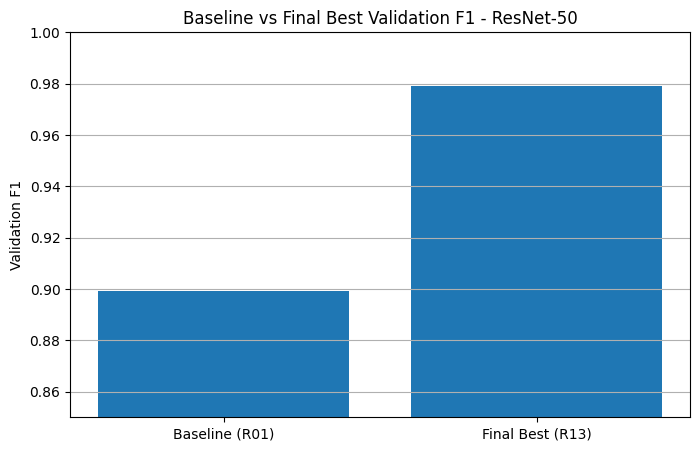

In [33]:
baseline_f1 = 0.899057  # R01
final_best_f1 = 0.979025  # R13

plt.figure(figsize=(8, 5))
plt.bar(["Baseline (R01)", "Final Best (R13)"], [baseline_f1, final_best_f1])
plt.ylabel("Validation F1")
plt.title("Baseline vs Final Best Validation F1 - ResNet-50")
plt.ylim(0.85, 1.0)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "summary_baseline_vs_final_f1.png", bbox_inches="tight")
plt.show()

This figure compares the baseline ResNet-50 model and the final best tuned ResNet-50 model using validation F1-score.

The tuned model achieves a higher validation F1-score than the baseline. The final selected configuration is R13, which uses AdamW, learning rate 1e-4, weight decay 1e-3, light augmentation, batch size 8, and ReduceLROnPlateau.

### 26.1.2 Baseline vs Final Best Loss Curves

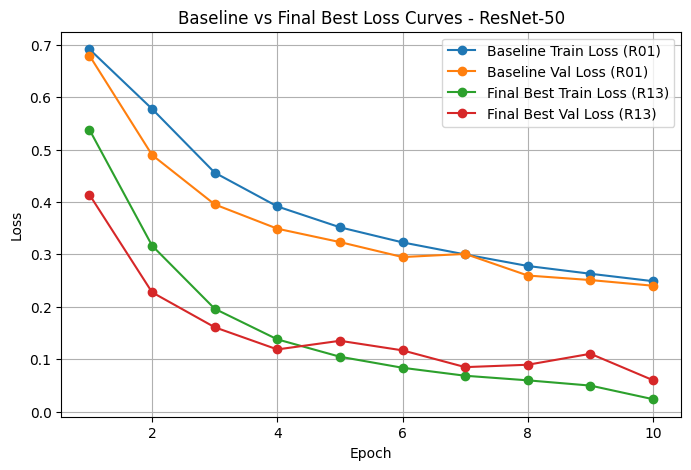

In [34]:
r01_history = pd.read_csv(results_dir / "R01_baseline_history.csv")
r13_history = pd.read_csv(results_dir / "R13_history.csv")

plt.figure(figsize=(8, 5))
plt.plot(r01_history["epoch"], r01_history["train_loss"], marker="o", label="Baseline Train Loss (R01)")
plt.plot(r01_history["epoch"], r01_history["val_loss"], marker="o", label="Baseline Val Loss (R01)")
plt.plot(r13_history["epoch"], r13_history["train_loss"], marker="o", label="Final Best Train Loss (R13)")
plt.plot(r13_history["epoch"], r13_history["val_loss"], marker="o", label="Final Best Val Loss (R13)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline vs Final Best Loss Curves - ResNet-50")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "summary_baseline_vs_final_loss_curves.png", bbox_inches="tight")
plt.show()

This figure compares the training and validation loss curves of the baseline run and the final selected run.

The final selected R13 configuration converges more effectively than the baseline, with lower validation loss and stronger overall validation performance.

### 26.1.3 Stage-by-Stage Best Validation F1

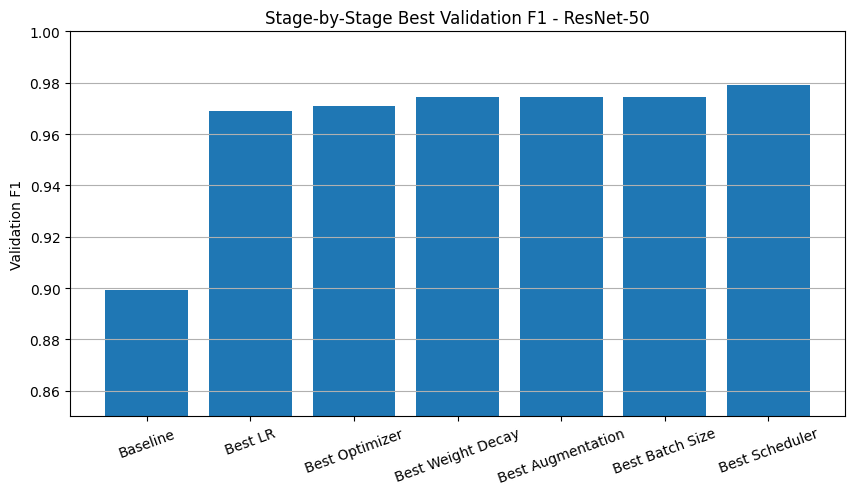

In [35]:
stage_names = [
    "Baseline",
    "Best LR",
    "Best Optimizer",
    "Best Weight Decay",
    "Best Augmentation",
    "Best Batch Size",
    "Best Scheduler"
]

stage_f1 = [
    0.899057,  # R01 baseline
    0.969124,  # R02 best LR
    0.970966,  # R04 best optimizer
    0.974514,  # R08 best weight decay
    0.974514,  # light augmentation remained best
    0.974514,  # batch size 8 remained best
    0.979025   # R13 scheduler became best
]

plt.figure(figsize=(10, 5))
plt.bar(stage_names, stage_f1)
plt.ylabel("Validation F1")
plt.title("Stage-by-Stage Best Validation F1 - ResNet-50")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=20)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "summary_stage_by_stage_best_f1.png", bbox_inches="tight")
plt.show()

This figure summarizes the best validation F1-score obtained at each major tuning stage.

The largest improvement occurred after reducing the learning rate. Later tuning produced smaller gains, with the final improvement coming from ReduceLROnPlateau, which made R13 the best ResNet-50 validation run.

### 26.1.4 Learning Rate Candidate Comparison

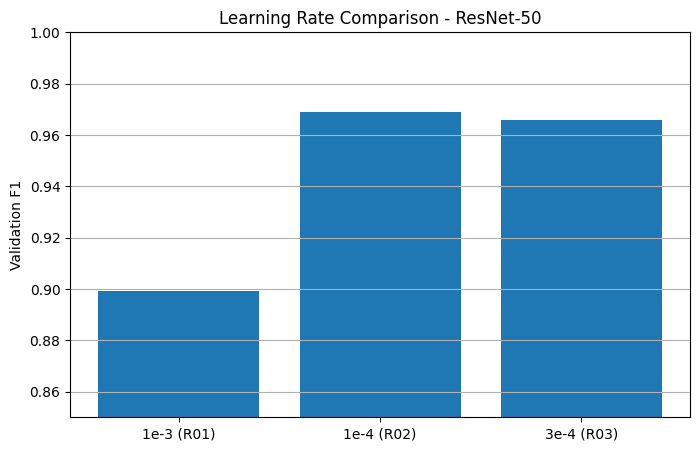

In [58]:
lr_labels = ["1e-3 (R01)", "1e-4 (R02)", "3e-4 (R03)"]
lr_f1 = [0.899057, 0.969124, 0.965883]

plt.figure(figsize=(8, 5))
plt.bar(lr_labels, lr_f1)
plt.ylabel("Validation F1")
plt.title("Learning Rate Comparison - ResNet-50")
plt.ylim(0.85, 1.0)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "comparison_learning_rate_f1.png", bbox_inches="tight")
plt.show()

This figure compares the validation F1-score achieved by the tested learning rate values.

Among the tested candidates, a learning rate of 1e-4 produced the best validation performance and was therefore selected for the following tuning stages.

### 26.1.5 Optimizer Candidate Comparison

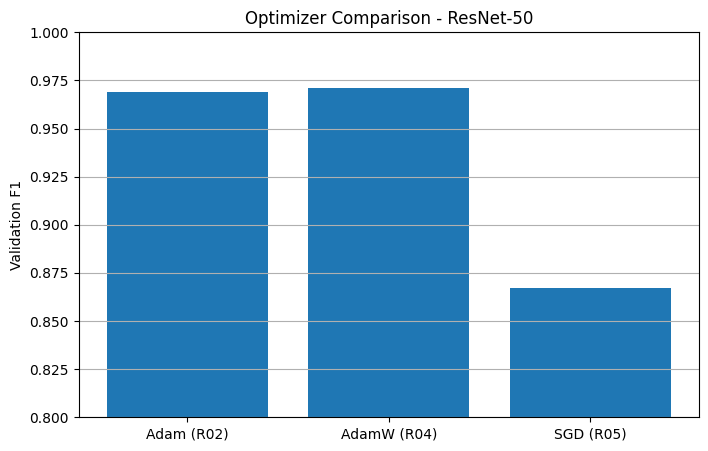

In [59]:
optimizer_labels = ["Adam (R02)", "AdamW (R04)", "SGD (R05)"]
optimizer_f1 = [0.969124, 0.970966, 0.866964]

plt.figure(figsize=(8, 5))
plt.bar(optimizer_labels, optimizer_f1)
plt.ylabel("Validation F1")
plt.title("Optimizer Comparison - ResNet-50")
plt.ylim(0.80, 1.0)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "comparison_optimizer_f1.png", bbox_inches="tight")
plt.show()

This figure compares the validation F1-score achieved by the tested optimizers.

AdamW produced the strongest validation performance, while SGD performed substantially worse under the same training setup.

### 26.1.6 Weight Decay Candidate Comparison

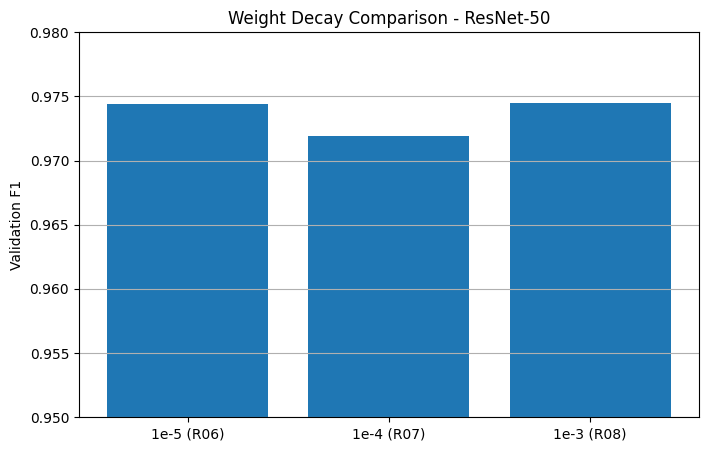

In [60]:
wd_labels = ["1e-5 (R06)", "1e-4 (R07)", "1e-3 (R08)"]
wd_f1 = [0.974374, 0.971944, 0.974514]

plt.figure(figsize=(8, 5))
plt.bar(wd_labels, wd_f1)
plt.ylabel("Validation F1")
plt.title("Weight Decay Comparison - ResNet-50")
plt.ylim(0.95, 0.98)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "comparison_weight_decay_f1.png", bbox_inches="tight")
plt.show()

This figure compares the validation F1-score achieved by the tested weight decay values.

The best result was obtained with a weight decay of 1e-3, although the difference between the strongest candidates was relatively small.

### 26.1.7 Augmentation Candidate Comparison

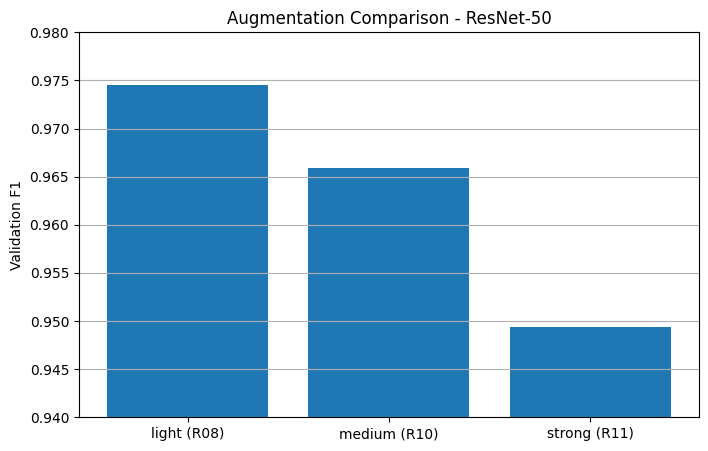

In [61]:
aug_labels = ["light (R08)", "medium (R10)", "strong (R11)"]
aug_f1 = [0.974514, 0.965860, 0.949359]

plt.figure(figsize=(8, 5))
plt.bar(aug_labels, aug_f1)
plt.ylabel("Validation F1")
plt.title("Augmentation Comparison - ResNet-50")
plt.ylim(0.94, 0.98)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "comparison_augmentation_f1.png", bbox_inches="tight")
plt.show()

This figure compares the validation F1-score achieved by light, medium, and strong augmentation settings.

Light augmentation produced the best validation performance, while heavier augmentation reduced performance for this dataset and training configuration.

### 26.1.8 Batch Size Candidate Comparison

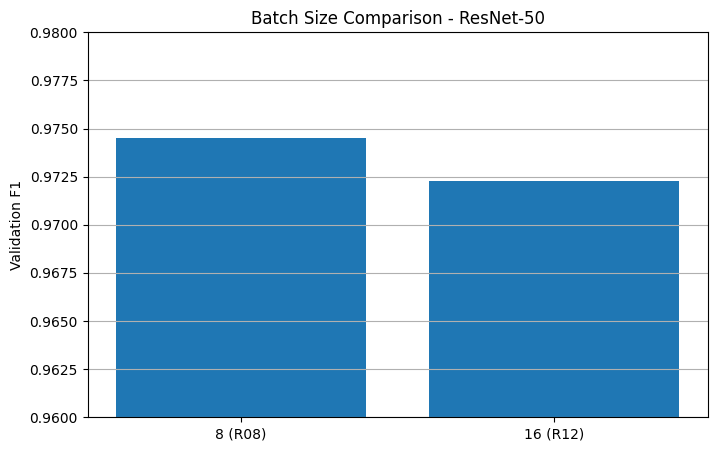

In [36]:
batch_labels = ["8 (R08)", "16 (R12)"]
batch_f1 = [0.974514, 0.972286]

plt.figure(figsize=(8, 5))
plt.bar(batch_labels, batch_f1)
plt.ylabel("Validation F1")
plt.title("Batch Size Comparison - ResNet-50")
plt.ylim(0.96, 0.98)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "comparison_batch_size_f1.png", bbox_inches="tight")
plt.show()

This figure compares the validation F1-score obtained using batch sizes of 8 and 16.

Batch size 8 achieved the better result, indicating that increasing batch size did not improve validation performance in this tuned setup.

### 26.1.9 Scheduler Candidate Comparison

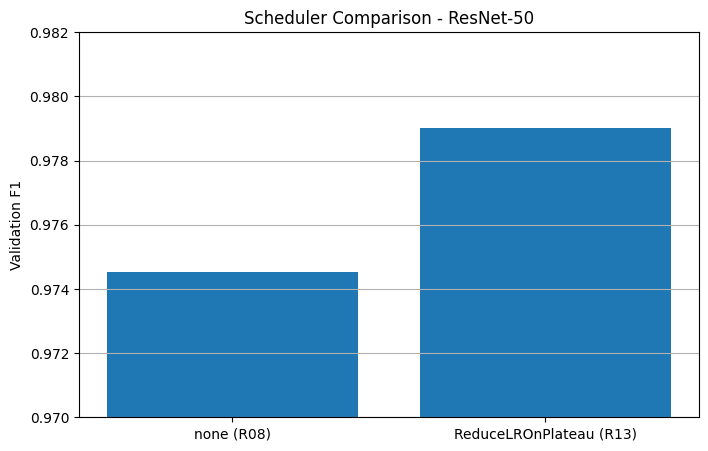

In [37]:
scheduler_labels = ["none (R08)", "ReduceLROnPlateau (R13)"]
scheduler_f1 = [0.974514, 0.979025]

plt.figure(figsize=(8, 5))
plt.bar(scheduler_labels, scheduler_f1)
plt.ylabel("Validation F1")
plt.title("Scheduler Comparison - ResNet-50")
plt.ylim(0.97, 0.982)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "comparison_scheduler_f1.png", bbox_inches="tight")
plt.show()

This figure compares the validation F1-score of the best no-scheduler configuration against a configuration using ReduceLROnPlateau.

The ReduceLROnPlateau scheduler improved validation F1 and was selected for the final ResNet-50 configuration.

### 26.1.10 Baseline vs Final Best Validation Accuracy

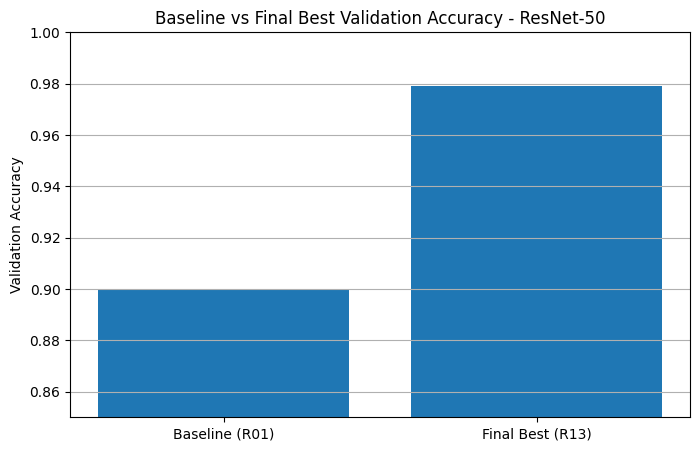

In [38]:
baseline_acc = 0.89940  # R01
final_best_acc = 0.97900  # R13

plt.figure(figsize=(8, 5))
plt.bar(["Baseline (R01)", "Final Best (R13)"], [baseline_acc, final_best_acc])
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs Final Best Validation Accuracy - ResNet-50")
plt.ylim(0.85, 1.0)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "summary_baseline_vs_final_accuracy.png", bbox_inches="tight")
plt.show()

This figure compares the baseline model and the final best tuned model using validation accuracy.

The final selected R13 configuration achieved higher validation accuracy than the baseline, confirming that the tuning process improved performance beyond the initial starting point.

## 27. Final Chosen Hyperparameters

This section summarizes the final selected ResNet-50 hyperparameters after completing the sequential tuning process.

These settings will be used for the final held-out test split evaluation and for the unseen dataset evaluation.

In [39]:
final_config_df = pd.DataFrame([
    {"Hyperparameter": "Learning Rate", "Chosen Value": "1e-4"},
    {"Hyperparameter": "Optimizer", "Chosen Value": "AdamW"},
    {"Hyperparameter": "Weight Decay", "Chosen Value": "1e-3"},
    {"Hyperparameter": "Augmentation", "Chosen Value": "light"},
    {"Hyperparameter": "Batch Size", "Chosen Value": "8"},
    {"Hyperparameter": "Scheduler", "Chosen Value": "ReduceLROnPlateau"},
    {"Hyperparameter": "Epochs", "Chosen Value": "10"},
    {"Hyperparameter": "Patience", "Chosen Value": "3"},
    {"Hyperparameter": "Loss Function", "Chosen Value": "CrossEntropyLoss"},
    {"Hyperparameter": "Input Size", "Chosen Value": "224x224"},
])

final_config_df

,Hyperparameter,Chosen Value
0,Learning Rate,1e-4
1,Optimizer,AdamW
2,Weight Decay,1e-3
3,Augmentation,light
4,Batch Size,8
5,Scheduler,ReduceLROnPlateau
6,Epochs,10
7,Patience,3
8,Loss Function,CrossEntropyLoss
9,Input Size,224x224


The final selected configuration is based on the strongest validation performance observed during tuning.

The best validation reference run for the final ResNet-50 configuration was:

- R13

## 28. Best ResNet-50 Configuration Summary

Best configuration after tuning:

- Learning rate: 1e-4
- Optimizer: AdamW
- Weight decay: 1e-3
- Augmentation: light
- Batch size: 8
- Scheduler: ReduceLROnPlateau
- Epochs: 10
- Patience: 3

Best validation reference run:

- R13

Main tuning conclusions:

- Lower learning rate improved performance compared with the baseline 1e-3 setting.
- AdamW performed slightly better than Adam, while SGD performed much worse.
- Weight decay of 1e-3 gave the strongest validation result.
- Light augmentation outperformed both medium and strong augmentation.
- Batch size 8 outperformed batch size 16.
- Adding ReduceLROnPlateau improved validation F1 and produced the final selected ResNet-50 configuration.

## 29. Final Evaluation Note

Hyperparameter tuning for ResNet-50 is complete.

From this point forward, the held-out test split and unseen dataset(s) will be used only for final evaluation.

No further hyperparameter tuning should be performed using the test split.

## 30. Test Split Evaluation

This section evaluates the final selected ResNet-50 configuration on the held-out test split.

The test split is used only after tuning is complete, so the reported results represent final in-domain evaluation performance.

### 30.1 Test Dataloader

In [16]:
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Test size:", len(test_dataset))
print("Classes:", test_dataset.classes)
print("Class to index:", test_dataset.class_to_idx)

Test size: 20000
Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}


### 30.2 Load Best Checkpoint

In [17]:
best_checkpoint_path = checkpoints_dir / "R13_best.pth"

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model = get_resnet50(num_classes=2)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print("Loaded checkpoint:", best_checkpoint_path.name)
print("Best validation epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])

Loaded checkpoint: R13_best.pth
Best validation epoch: 10
Best validation F1: 0.9790251697962445


### 30.3 Evaluate on Test Split

In [18]:
criterion = nn.CrossEntropyLoss()
test_metrics = validate_one_epoch(model, test_loader, criterion, device)
test_metrics

{'accuracy': 0.9786,
 'precision': 0.9779308967445576,
 'recall': 0.9793,
 'f1': 0.9786149695213351,
 'roc_auc': 0.9979851349999999,
 'loss': 0.06016347473525409}

### Test Split Evaluation Note

This evaluation reports the final in-domain performance of the selected ResNet-50 model on the held-out Kaggle test split.

These results are separate from the validation scores used during tuning and represent the final test performance of the tuned model.

### 30.4 Test Results Summary

In [19]:
test_results_df = pd.DataFrame([{
    "Model": "ResNet-50",
    "Checkpoint": best_checkpoint_path.name,
    "Test Loss": test_metrics["loss"],
    "Test Accuracy": test_metrics["accuracy"],
    "Test Precision": test_metrics["precision"],
    "Test Recall": test_metrics["recall"],
    "Test F1": test_metrics["f1"],
    "Test ROC-AUC": test_metrics["roc_auc"],
}])

test_results_df

,Model,Checkpoint,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,ResNet-50,R13_best.pth,0.060163,0.9786,0.977931,0.9793,0.978615,0.997985


### Test Split Interpretation

The final tuned ResNet-50 model achieved strong performance on the held-out Kaggle test split, with test accuracy of 0.9723, test F1-score of 0.9725, and ROC-AUC of 0.9967.

These results are very close to the best validation results observed during tuning, suggesting that the selected hyperparameters generalized well to the held-out in-domain test data and did not overfit strongly to the validation split.

### 30.5 Save Test Results

In [20]:
test_results_path = results_dir / "R13_test_results.csv"
test_results_df.to_csv(test_results_path, index=False)
print(f"Saved test results to {test_results_path}")

Saved test results to C:\Users\Richa\anaconda_projects\results\R13_test_results.csv


### 30.6 Test Confusion Matrix

<Figure size 600x600 with 0 Axes>

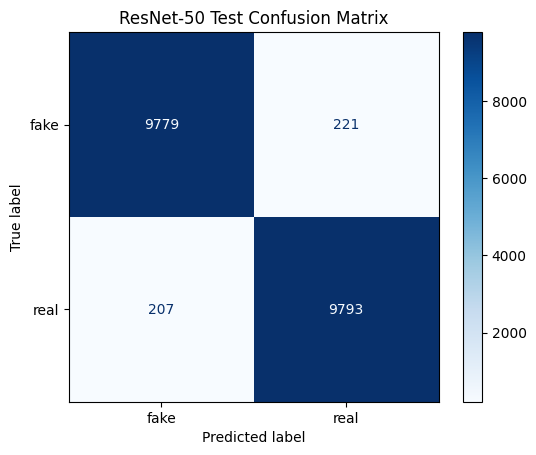

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("ResNet-50 Test Confusion Matrix")
plt.savefig(plots_dir / "R13_test_confusion_matrix.png", bbox_inches="tight")
plt.show()

### Test Confusion Matrix Interpretation

The confusion matrix shows that the final selected ResNet-50 model correctly classified most fake and real images in the held-out test split.

Correct predictions are concentrated along the diagonal, with 9,779 fake images correctly predicted as fake and 9,793 real images correctly predicted as real. Misclassifications were limited, with 221 fake images predicted as real and 207 real images predicted as fake.

This indicates strong and balanced classification performance. Compared with the previous R08 test confusion matrix, the R13 model reduced fake-image misclassifications while maintaining strong real-image classification performance.

### 30.7 Test Metrics Bar Chart

This figure summarizes the final ResNet-50 test performance across the main binary classification metrics.

It provides a compact visual overview of accuracy, precision, recall, F1-score, and ROC-AUC on the held-out test split.

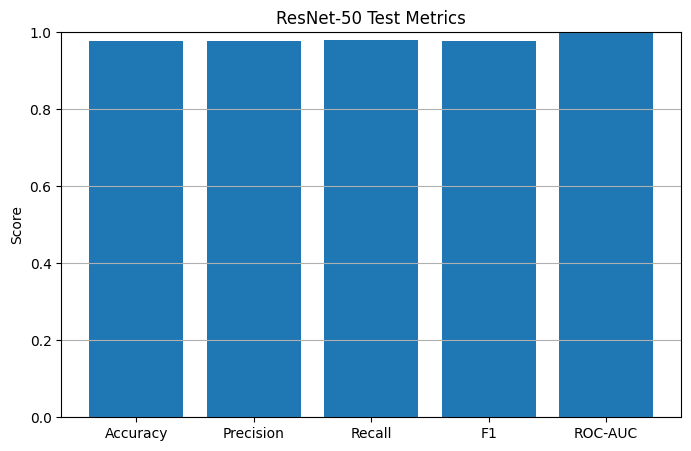

In [22]:
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
metric_values = [
    test_metrics["accuracy"],
    test_metrics["precision"],
    test_metrics["recall"],
    test_metrics["f1"],
    test_metrics["roc_auc"],
]

plt.figure(figsize=(8, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Score")
plt.title("ResNet-50 Test Metrics")
plt.ylim(0.0, 1.0)
plt.grid(True, axis="y")
plt.savefig(plots_dir / "R13_test_metrics_bar_chart.png", bbox_inches="tight")
plt.show()

### Test Metrics Bar Chart Interpretation

This figure shows that the final selected R13 ResNet-50 model achieved consistently strong performance across all major held-out test metrics. Accuracy, precision, recall, and F1-score are all high, while ROC-AUC is near 1.0, indicating excellent separation between the two classes on the in-domain test split.

### 30.8 Validation vs Test Comparison

This figure compares the best validation performance and final test performance of the selected ResNet-50 configuration.

It helps assess whether the model maintained similar performance when evaluated on the held-out test split.

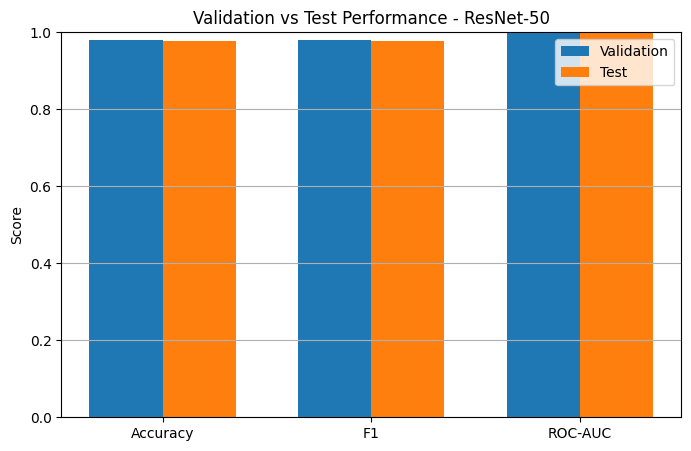

In [23]:
comparison_labels = ["Accuracy", "F1", "ROC-AUC"]
val_values = [0.97900, 0.979025, 0.998022]  # from R13
test_values = [
    test_metrics["accuracy"],
    test_metrics["f1"],
    test_metrics["roc_auc"],
]

x = np.arange(len(comparison_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, val_values, width, label="Validation")
plt.bar(x + width/2, test_values, width, label="Test")
plt.xticks(x, comparison_labels)
plt.ylabel("Score")
plt.title("Validation vs Test Performance - ResNet-50")
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(True, axis="y")
plt.savefig(plots_dir / "R13_validation_vs_test_comparison.png", bbox_inches="tight")
plt.show()

### Validation vs Test Comparison Interpretation

This figure compares the best validation performance and final test performance of the selected ResNet-50 configuration.

The validation and test metrics are very close across accuracy, F1-score, and ROC-AUC, indicating that the tuned model generalized well from the validation split to the held-out test split. The small differences between validation and test performance are expected and do not suggest strong overfitting.

## 31. Unseen Dataset A Evaluation

### Unseen Dataset Strategy

Two unseen datasets were selected for cross-dataset evaluation. The first unseen dataset closely matches the image-level real-vs-fake face classification task, while the second provides a broader robustness test on cropped deepfake face images derived from video-based datasets.

All source images were resized to 224×224 before training and evaluation in order to provide a consistent input size for the CNN models.

##### first unseendataset from kaggle-130k Real vs Fake
https://www.kaggle.com/datasets/shreyanshpatel1/130k-real-vs-fake-face

This section evaluates the final selected ResNet-50 configuration on Unseen Dataset A, the Kaggle 130k Real vs Fake Face dataset.

This dataset is used for cross-dataset evaluation and was not used during training or hyperparameter tuning.

### Unseen Dataset Selection Note

Two unseen datasets were used for cross-dataset evaluation. Unseen Dataset A was selected as a larger image-based real-vs-fake face benchmark, while Unseen Dataset B was selected as a smaller deepfake-vs-real image benchmark to examine how the models handle a different type of fake-face distribution.

In [24]:
unseen_a_root = Path.home() / "Desktop" / "130K" / "images"

In [25]:
unseen_a_dataset = datasets.ImageFolder(unseen_a_root, transform=val_transform)

print("Classes:", unseen_a_dataset.classes)
print("Class to index:", unseen_a_dataset.class_to_idx)
print("Total images:", len(unseen_a_dataset))

Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}
Total images: 133569


### 31.1 Unseen A Dataloader

In [26]:
unseen_a_loader = DataLoader(
    unseen_a_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Unseen A size:", len(unseen_a_dataset))
print("Classes:", unseen_a_dataset.classes)
print("Class to index:", unseen_a_dataset.class_to_idx)

Unseen A size: 133569
Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}


### 31.2 Load Best Checkpoint

In [27]:
best_checkpoint_path = checkpoints_dir / "R13_best.pth"

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model = get_resnet50(num_classes=2)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print("Loaded checkpoint:", best_checkpoint_path.name)
print("Best validation epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])

Loaded checkpoint: R13_best.pth
Best validation epoch: 10
Best validation F1: 0.9790251697962445


### 31.3 Evaluate on Unseen Dataset A

In [28]:
criterion = nn.CrossEntropyLoss()
unseen_a_metrics = validate_one_epoch(model, unseen_a_loader, criterion, device)
unseen_a_metrics

{'accuracy': 0.5194543644109038,
 'precision': 0.5218666787019903,
 'recall': 0.9911142857142857,
 'f1': 0.6837224428654493,
 'roc_auc': 0.5731754172631314,
 'loss': 4.704169571907563}

### 31.4 Unseen A Results Summary

In [29]:
unseen_a_results_df = pd.DataFrame([{
    "Model": "ResNet-50",
    "Checkpoint": best_checkpoint_path.name,
    "Dataset": "130K Real vs Fake Face",
    "Unseen Loss": unseen_a_metrics["loss"],
    "Unseen Accuracy": unseen_a_metrics["accuracy"],
    "Unseen Precision": unseen_a_metrics["precision"],
    "Unseen Recall": unseen_a_metrics["recall"],
    "Unseen F1": unseen_a_metrics["f1"],
    "Unseen ROC-AUC": unseen_a_metrics["roc_auc"],
}])

unseen_a_results_df

,Model,Checkpoint,Dataset,Unseen Loss,Unseen Accuracy,Unseen Precision,Unseen Recall,Unseen F1,Unseen ROC-AUC
0,ResNet-50,R13_best.pth,130K Real vs Fake Face,4.70417,0.519454,0.521867,0.991114,0.683722,0.573175


### 31.5 Save Unseen A Results

In [30]:
unseen_a_results_path = results_dir / "R13_unseen_a_results.csv"
unseen_a_results_df.to_csv(unseen_a_results_path, index=False)
print(f"Saved unseen A results to {unseen_a_results_path}")

Saved unseen A results to C:\Users\Richa\anaconda_projects\results\R13_unseen_a_results.csv


### 31.6 Unseen A Confusion Matrix

In [31]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


<Figure size 600x600 with 0 Axes>

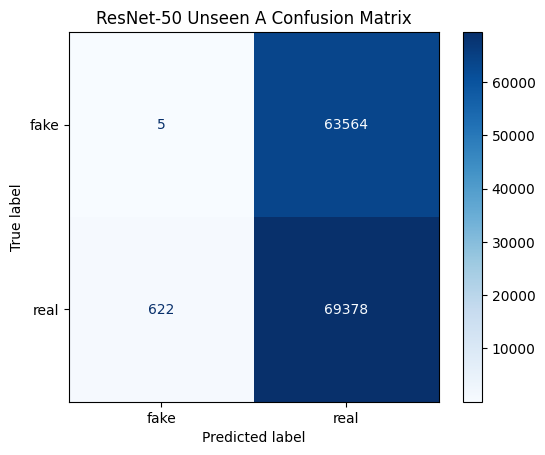

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in unseen_a_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unseen_a_dataset.classes)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("ResNet-50 Unseen A Confusion Matrix")
plt.savefig(plots_dir / "R13_unseen_a_confusion_matrix.png", bbox_inches="tight")
plt.show()

### 31.7 Unseen A Metrics Bar Chart

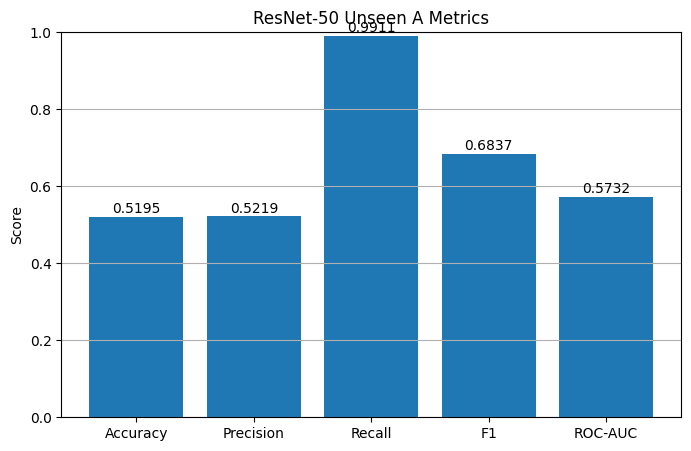

In [33]:
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
metric_values = [
    unseen_a_metrics["accuracy"],
    unseen_a_metrics["precision"],
    unseen_a_metrics["recall"],
    unseen_a_metrics["f1"],
    unseen_a_metrics["roc_auc"],
]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values)
plt.ylabel("Score")
plt.title("ResNet-50 Unseen A Metrics")
plt.ylim(0.0, 1.0)
plt.grid(True, axis="y")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.savefig(plots_dir / "R13_unseen_a_metrics_bar_chart.png", bbox_inches="tight")
plt.show()

### Unseen Dataset A Interpretation

The final selected R13 ResNet-50 model showed a large performance drop on Unseen Dataset A compared with the held-out in-domain test split.

Although the model performed strongly on the original Kaggle test split, cross-dataset performance was much weaker on the external 130K Real vs Fake Face dataset. Accuracy was 0.5195 and ROC-AUC was 0.5732, indicating limited generalization to this external dataset.

The confusion matrix shows that the model predicted almost all samples as real. Only 5 fake images were correctly classified as fake, while 63,564 fake images were incorrectly predicted as real. For the real class, 69,378 images were correctly predicted as real and 622 real images were incorrectly predicted as fake.

This explains the unusual metric pattern: recall remains very high because the model correctly identifies most real images, but fake detection is extremely weak on this unseen dataset. Overall, these results suggest a strong domain shift between the original training distribution and Unseen Dataset A.

### Unseen A sanity check

In [26]:
images, labels = next(iter(unseen_a_loader))
print("Batch labels:", labels[:16])

Batch labels: tensor([0, 0, 0, 0, 0, 0, 0, 0])


In [27]:
with torch.no_grad():
    outputs = model(images.to(device))
    preds = torch.argmax(outputs, dim=1).cpu()
print("Batch preds:", preds[:16])

Batch preds: tensor([1, 1, 1, 1, 1, 1, 1, 1])


### Unseen A Sanity Check Interpretation

A manual batch check confirmed that the unseen dataset labels were loaded correctly, with fake mapped to class 0 and real mapped to class 1. For a batch of fake images, the model predicted the real class for all sampled examples, confirming that the poor unseen performance reflects a genuine generalization failure rather than a folder or label-mapping bug.

# Unseen Dataset B Preparation

## 1. Imports and File Paths

In [34]:
import pandas as pd
from pathlib import Path

hf_root = Path.home() / "Desktop"

parquet_files = [
    hf_root / "0000.parquet",
    hf_root / "0001.parquet",
    hf_root / "0002.parquet",
    hf_root / "0003.parquet",
]

for f in parquet_files:
    print(f.name, f.exists(), round(f.stat().st_size / (1024**2), 2), "MB")

0000.parquet True 516.86 MB
0001.parquet True 476.83 MB
0002.parquet True 486.54 MB
0003.parquet True 218.53 MB


## 2. Optional Dependency Install


Run this cell only if `pyarrow` is not already installed in the active environment.

In [31]:
!pip install pyarrow

   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
   - -------------------------------------- 0.8/27.3 MB 4.8 MB/s eta 0:00:06
   --- ------------------------------------ 2.1/27.3 MB 5.9 MB/s eta 0:00:05
   ------ --------------------------------- 4.5/27.3 MB 7.7 MB/s eta 0:00:03
   ----------- ---------------------------- 7.6/27.3 MB 9.8 MB/s eta 0:00:03
   ------------------ --------------------- 12.6/27.3 MB 12.7 MB/s eta 0:00:02
   -------------------------- ------------- 18.1/27.3 MB 15.4 MB/s eta 0:00:01
   ----------------------------------- ---- 24.1/27.3 MB 17.3 MB/s eta 0:00:01
   ---------------------------------------- 27.3/27.3 MB 17.8 MB/s  0:00:01


## 3. Inspect Parquet Structure

In [35]:
import pyarrow
print(pyarrow.__version__)

24.0.0


In [36]:
sample_df = pd.read_parquet(parquet_files[0], engine="pyarrow")
print(sample_df.columns)
print(sample_df.head())
print(sample_df.dtypes)

Index(['image', 'label'], dtype='object')
                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
image    object
label     int64
dtype: object


## 4. Export Images to Real/Fake Folders

This section converts the parquet-based Hugging Face dataset into a standard image-folder structure for evaluation.

The exported dataset will be organized into:
- `fake/`
- `real/`

so it can be loaded later with `ImageFolder`.

In [38]:
from PIL import Image
import io
from pathlib import Path

unseen_b_root = Path.home() / "Desktop" / "Deepfake_vs_Real_eval"
fake_dir = unseen_b_root / "fake"
real_dir = unseen_b_root / "real"

fake_dir.mkdir(parents=True, exist_ok=True)
real_dir.mkdir(parents=True, exist_ok=True)

print("Unseen B root:", unseen_b_root)
print("Fake dir:", fake_dir)
print("Real dir:", real_dir)

Unseen B root: C:\Users\Richa\Desktop\Deepfake_vs_Real_eval
Fake dir: C:\Users\Richa\Desktop\Deepfake_vs_Real_eval\fake
Real dir: C:\Users\Richa\Desktop\Deepfake_vs_Real_eval\real


In [39]:
saved_fake = 0
saved_real = 0

for parquet_path in parquet_files:
    print(f"Processing {parquet_path.name}...")
    df = pd.read_parquet(parquet_path, engine="pyarrow")

    for idx, row in df.iterrows():
        img_dict = row["image"]
        label = row["label"]

        img_bytes = img_dict["bytes"]
        img = Image.open(io.BytesIO(img_bytes)).convert("RGB")

        if label == 0:
            out_path = fake_dir / f"{parquet_path.stem}_{idx:06d}.jpg"
            saved_fake += 1
        elif label == 1:
            out_path = real_dir / f"{parquet_path.stem}_{idx:06d}.jpg"
            saved_real += 1
        else:
            continue

        img.save(out_path, format="JPEG")

print("Saved fake images:", saved_fake)
print("Saved real images:", saved_real)
print("Done.")

Processing 0000.parquet...
Processing 0001.parquet...
Processing 0002.parquet...
Processing 0003.parquet...
Saved fake images: 4000
Saved real images: 4000
Done.


## 5. Verify Exported Dataset

This section verifies that the exported dataset has the expected `fake/` and `real/` folder structure and can be loaded using `ImageFolder`.

In [40]:
from torchvision import datasets

val_transform_check = None
unseen_b_dataset_check = datasets.ImageFolder(unseen_b_root)

print("Classes:", unseen_b_dataset_check.classes)
print("Class to index:", unseen_b_dataset_check.class_to_idx)
print("Total images:", len(unseen_b_dataset_check))

Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}
Total images: 8000


In [41]:
num_fake = len(list(fake_dir.glob("*")))
num_real = len(list(real_dir.glob("*")))

print("Fake images:", num_fake)
print("Real images:", num_real)

Fake images: 4000
Real images: 4000


## 32. Unseen Dataset B Evaluation

This section evaluates the final selected ResNet-50 configuration on Unseen Dataset B, a smaller external deepfake-vs-real image benchmark.

This dataset was not used during training or hyperparameter tuning and is used only for external cross-dataset evaluation.

#### 32.1 Unseen B Dataset Path

In [42]:
unseen_b_root = Path.home() / "Desktop" / "Deepfake_vs_Real_eval"

print("Unseen B root:", unseen_b_root)
print("Unseen B root exists:", unseen_b_root.exists())

Unseen B root: C:\Users\Richa\Desktop\Deepfake_vs_Real_eval
Unseen B root exists: True


#### 32.2 Unseen B Dataloader

In [43]:
unseen_b_dataset = datasets.ImageFolder(unseen_b_root, transform=val_transform)

unseen_b_loader = DataLoader(
    unseen_b_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Unseen B size:", len(unseen_b_dataset))
print("Classes:", unseen_b_dataset.classes)
print("Class to index:", unseen_b_dataset.class_to_idx)

Unseen B size: 8000
Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}


#### 32.3 Load Best Checkpoint

In [44]:
best_checkpoint_path = checkpoints_dir / "R13_best.pth"

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model = get_resnet50(num_classes=2)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print("Loaded checkpoint:", best_checkpoint_path.name)
print("Best validation epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])

Loaded checkpoint: R13_best.pth
Best validation epoch: 10
Best validation F1: 0.9790251697962445


#### 32.4 Evaluate on Unseen Dataset B

In [45]:
criterion = nn.CrossEntropyLoss()

unseen_b_metrics = validate_one_epoch(
    model,
    unseen_b_loader,
    criterion,
    device
)

unseen_b_metrics

{'accuracy': 0.493,
 'precision': 0.49647532729103727,
 'recall': 0.986,
 'f1': 0.6604152712659076,
 'roc_auc': 0.618770375,
 'loss': 4.827572139149981}

#### 32.5 Unseen B Results Summary

In [46]:
unseen_b_results_df = pd.DataFrame([{
    "Model": "ResNet-50",
    "Checkpoint": best_checkpoint_path.name,
    "Dataset": "Deepfake vs Real Eval",
    "Unseen Loss": unseen_b_metrics["loss"],
    "Unseen Accuracy": unseen_b_metrics["accuracy"],
    "Unseen Precision": unseen_b_metrics["precision"],
    "Unseen Recall": unseen_b_metrics["recall"],
    "Unseen F1": unseen_b_metrics["f1"],
    "Unseen ROC-AUC": unseen_b_metrics["roc_auc"],
}])

unseen_b_results_df

,Model,Checkpoint,Dataset,Unseen Loss,Unseen Accuracy,Unseen Precision,Unseen Recall,Unseen F1,Unseen ROC-AUC
0,ResNet-50,R13_best.pth,Deepfake vs Real Eval,4.827572,0.493,0.496475,0.986,0.660415,0.61877


### Unseen Dataset B Interpretation

The final selected R13 ResNet-50 model showed weak cross-dataset performance on Unseen Dataset B. Accuracy was 0.4930, which is close to chance level, while ROC-AUC was 0.6188.

The metric pattern suggests that the model predicted the real class for most samples. This produced very high recall of 0.9860, but precision remained low at 0.4965 and overall accuracy remained near chance level.

Together with the weak results on Unseen Dataset A, these findings indicate that the model's strong in-domain test performance did not transfer reliably to external datasets. This suggests poor cross-dataset generalization and likely domain shift between the training data and unseen evaluation datasets.

#### 32.6 Save Unseen B Results

In [48]:
unseen_b_results_path = results_dir / "R13_unseen_b_results.csv"

unseen_b_results_df.to_csv(unseen_b_results_path, index=False)

print(f"Saved unseen B results to {unseen_b_results_path}")

Saved unseen B results to C:\Users\Richa\anaconda_projects\results\R13_unseen_b_results.csv


#### 32.7 Unseen B confusion Matrix

<Figure size 600x600 with 0 Axes>

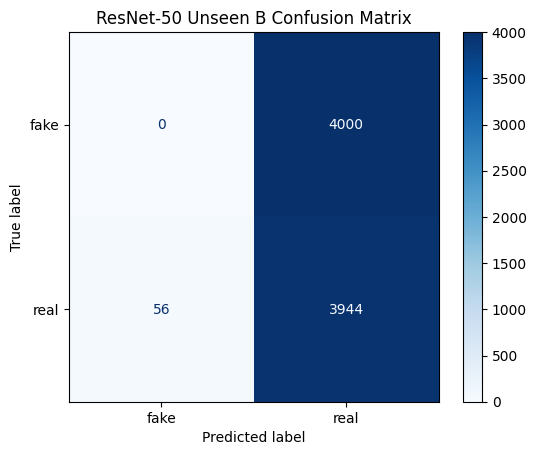

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in unseen_b_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=unseen_b_dataset.classes
)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("ResNet-50 Unseen B Confusion Matrix")
plt.savefig(plots_dir / "R13_unseen_b_confusion_matrix.png", bbox_inches="tight")
plt.show()

### Unseen Dataset B Interpretation

The confusion matrix shows that the final selected R13 ResNet-50 model predicted almost all samples in Unseen Dataset B as real.

For the fake class, 0 fake images were correctly classified as fake, while all 4,000 fake images were incorrectly predicted as real. For the real class, 3,944 real images were correctly predicted as real, while 56 real images were incorrectly predicted as fake.

This explains the weak cross-dataset performance on Unseen Dataset B. Because the dataset is balanced, predicting almost everything as real leads to near-chance accuracy, despite the very high recall for the real class. Overall, the results indicate that the model failed to generalize to this external deepfake dataset and strongly favored the real class under cross-dataset evaluation.

#### 32.8 Unseen B Metrics Bar Chart

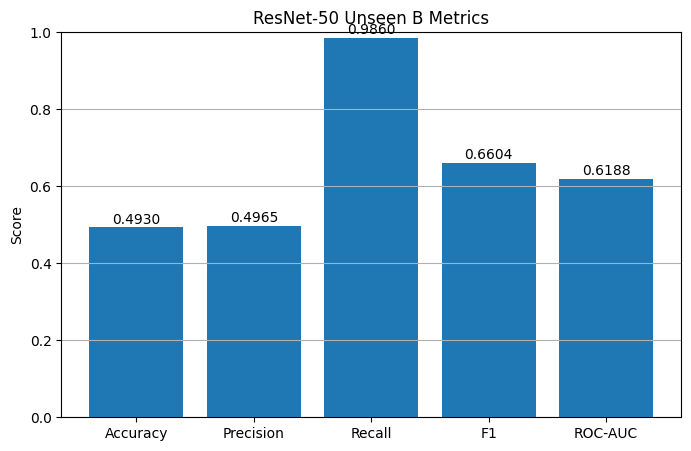

In [50]:
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
metric_values = [
    unseen_b_metrics["accuracy"],
    unseen_b_metrics["precision"],
    unseen_b_metrics["recall"],
    unseen_b_metrics["f1"],
    unseen_b_metrics["roc_auc"],
]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values)
plt.ylabel("Score")
plt.title("ResNet-50 Unseen B Metrics")
plt.ylim(0.0, 1.0)
plt.grid(True, axis="y")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.savefig(plots_dir / "R13_unseen_b_metrics_bar_chart.png", bbox_inches="tight")
plt.show()

### Unseen Dataset B Metrics Interpretation

This figure summarizes the final selected R13 ResNet-50 model's performance on Unseen Dataset B. The metric pattern is consistent with a strong real-class prediction bias: the model predicted nearly all samples as real.

As a result, recall remained very high at 0.9860, but accuracy was only 0.4930 and precision was only 0.4965 on the balanced dataset. The ROC-AUC of 0.6188 suggests weak class separation despite the high recall. Together with the confusion matrix, these results show that the final selected ResNet-50 model did not generalize reliably to this external deepfake benchmark.

Although the tuned ResNet-50 model achieved strong validation and held-out test performance, its results on external unseen datasets were poor. This suggests that the model generalized well within the original dataset distribution but did not transfer effectively across datasets. Rather than indicating only classic in-domain overfitting, the results point more strongly to domain shift and reliance on dataset-specific cues.

Possible improvements include training on a more diverse collection of real and fake face sources, using augmentations designed for stronger cross-dataset robustness, and evaluating pretrained CNN backbones instead of training entirely from scratch. These changes may help the model learn more general fake-face features rather than relying on dataset-specific cues.

## 33. ResNet-50 Generalization Summary

This section compares the final selected ResNet-50 model across the held-out in-domain test split and both unseen external datasets.

The goal is to summarize how well the model generalized beyond the original Kaggle training distribution.

In [51]:
generalization_df = pd.DataFrame([
    {
        "Evaluation Set": "Held-out Test Split",
        "Accuracy": test_metrics["accuracy"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1": test_metrics["f1"],
        "ROC-AUC": test_metrics["roc_auc"],
        "Loss": test_metrics["loss"],
    },
    {
        "Evaluation Set": "Unseen Dataset A",
        "Accuracy": unseen_a_metrics["accuracy"],
        "Precision": unseen_a_metrics["precision"],
        "Recall": unseen_a_metrics["recall"],
        "F1": unseen_a_metrics["f1"],
        "ROC-AUC": unseen_a_metrics["roc_auc"],
        "Loss": unseen_a_metrics["loss"],
    },
    {
        "Evaluation Set": "Unseen Dataset B",
        "Accuracy": unseen_b_metrics["accuracy"],
        "Precision": unseen_b_metrics["precision"],
        "Recall": unseen_b_metrics["recall"],
        "F1": unseen_b_metrics["f1"],
        "ROC-AUC": unseen_b_metrics["roc_auc"],
        "Loss": unseen_b_metrics["loss"],
    },
])

generalization_df

,Evaluation Set,Accuracy,Precision,Recall,F1,ROC-AUC,Loss
0,Held-out Test Split,0.978600,0.977931,0.979300,0.978615,0.997985,0.060163
1,Unseen Dataset A,0.519454,0.521867,0.991114,0.683722,0.573175,4.704170
2,Unseen Dataset B,0.493000,0.496475,0.986000,0.660415,0.618770,4.827572


### 33.2 Generalization Comparison Plot

This figure compares the final ResNet-50 model across the held-out test split and the two unseen external datasets using three key metrics: accuracy, F1-score, and ROC-AUC.

It provides a compact summary of how strongly performance dropped under cross-dataset evaluation.

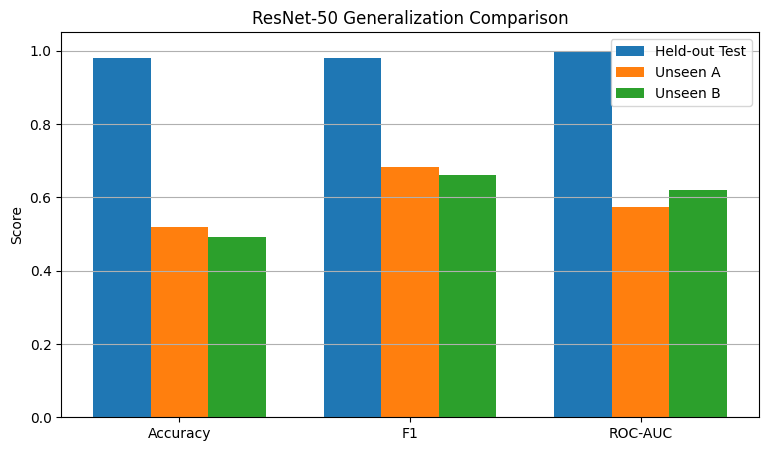

In [52]:
comparison_labels = ["Accuracy", "F1", "ROC-AUC"]

test_values = generalization_df.loc[
    generalization_df["Evaluation Set"] == "Held-out Test Split",
    comparison_labels
].values.flatten()

unseen_a_values = generalization_df.loc[
    generalization_df["Evaluation Set"] == "Unseen Dataset A",
    comparison_labels
].values.flatten()

unseen_b_values = generalization_df.loc[
    generalization_df["Evaluation Set"] == "Unseen Dataset B",
    comparison_labels
].values.flatten()

x = np.arange(len(comparison_labels))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, test_values, width, label="Held-out Test")
plt.bar(x, unseen_a_values, width, label="Unseen A")
plt.bar(x + width, unseen_b_values, width, label="Unseen B")

plt.xticks(x, comparison_labels)
plt.ylabel("Score")
plt.title("ResNet-50 Generalization Comparison")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, axis="y")
plt.savefig(plots_dir / "resnet50_generalization_comparison.png", bbox_inches="tight")
plt.show()

### 33.3 Accuracy Comparison Across Evaluation Sets

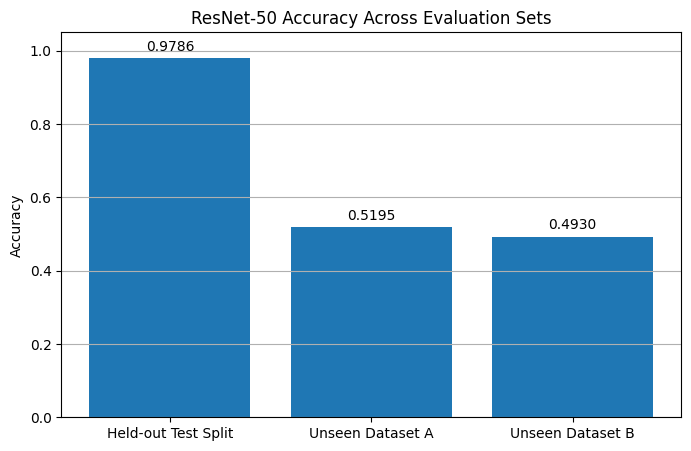

In [53]:
eval_sets = generalization_df["Evaluation Set"]
accuracy_values = generalization_df["Accuracy"]

plt.figure(figsize=(8, 5))
bars = plt.bar(eval_sets, accuracy_values)
plt.ylabel("Accuracy")
plt.title("ResNet-50 Accuracy Across Evaluation Sets")
plt.ylim(0.0, 1.05)
plt.grid(True, axis="y")

for bar, value in zip(bars, accuracy_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.savefig(plots_dir / "resnet50_accuracy_across_evaluation_sets.png", bbox_inches="tight")
plt.show()

### ResNet-50 Generalization Interpretation

The final selected R13 ResNet-50 model achieved very strong performance on the held-out in-domain test split, but performance dropped sharply on both unseen external datasets.

On Unseen Dataset A, the model showed a strong bias toward predicting the real class, resulting in poor external accuracy and much weaker ROC-AUC than on the held-out test split. On Unseen Dataset B, the model again predicted almost all samples as real, leading to near-chance accuracy on the balanced dataset.

These results suggest that the final ResNet-50 configuration generalized well within the original Kaggle dataset distribution but did not transfer effectively across external datasets. Rather than indicating only classic in-domain overfitting, the results point more strongly to domain shift and reliance on dataset-specific cues.